In [1]:
import xarray as xr
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm.auto import tqdm
import uqct

In [2]:
import glob

def read_dataset(*paths, dataset=None):
    # recursively read all netcdf files in path
    nc_files = []
    for path in paths:
        nc_files.extend(sorted(glob.glob(f"{path}/**/*.nc", recursive=True)))

    datasets = {}
    attrs = []
    for f in nc_files:
        # print(f)
        ds = xr.open_dataset(f)
        # print(ds.attrs)

        if dataset is not None:
            if ds.attrs["dataset"] != dataset:
                continue
        attrs.append(ds.attrs)
        experiment_id = ds.attrs['experiment_id']
        if not 'beta' in ds:
            ds['beta'] = ds['seq_nll'].cumsum(dim='step')
        # else:
        #     print((ds['beta'] - ds['seq_nll'].cumsum(dim='step')).max())
        if 'seq_nll_mix' in ds:
            if not 'beta_mix' in ds:
                ds['beta_mix'] = ds['seq_nll_mix'].cumsum(dim='step')
            # else:
            #     print((ds['beta_mix'] - ds['seq_nll_mix'].cumsum(dim='step')).max())
        datasets[experiment_id] = ds
    df = pd.DataFrame(attrs)
    df = df.set_index('experiment_id')
    return datasets, df

def find_experiment(attrs, datasets, dataset, model, samples=False, aggregate_seeds=False, match_attrs=None):
    if 'samples' in attrs.columns:
        matching_experiments = attrs.loc[(attrs['model'] == model) & (attrs['dataset'] == dataset) & (attrs['samples'] == samples)]
    else:
        matching_experiments = attrs.loc[(attrs['model'] == model) & (attrs['dataset'] == dataset)]

    if match_attrs is not None:
        for key, value in match_attrs.items():
            matching_experiments = matching_experiments.loc[matching_experiments[key] == str(value)]
    if len(matching_experiments) == 0:
        raise ValueError(f"No experiment found for model {model} and dataset {dataset}.")
    elif aggregate_seeds:
        if len(matching_experiments) == len(matching_experiments['seeds'].unique()):
            # print(f"INFO Aggregating {len(matching_experiments)} experiments for model {model} and dataset {dataset}.")
            # print(f"Aggregation {len(matching_experiments)} experiments for model {model} and dataset {dataset}.")

            all_ds = []
            for experiment_id in matching_experiments.index:
                ds = datasets[experiment_id].sel(model=model)
                all_ds.append(ds)
            ds = xr.concat(all_ds, dim='seed', data_vars='all')
            return ds, matching_experiments.index.values
        else:
            raise ValueError(f"WARNING Number of matching experiments {len(matching_experiments)} does not match number of unique seeds {len(matching_experiments['seeds'].unique())}. Not aggregating.")
    elif len(matching_experiments) > 1:
        raise ValueError(f"WARNING Multiple experiments found for model {model} and dataset {dataset}.")

    experiment_id = matching_experiments.index[0]
    ds = datasets[experiment_id].sel(model=model)
    return ds, experiment_id


# datasets, attrs = read_dataset("../results/2026-01-13/")
# datasets, attrs = read_dataset("../results/2026-01-13_30/")
# datasets, attrs = read_dataset("../results/2026-01-16/")
# datasets, attrs = read_dataset("../results/2026-01-16_30/")
# datasets, attrs = read_dataset("../results/2026-01-19_fix/")
# datasets, attrs = read_dataset("../results/2026-01-20/")
# datasets, attrs = read_dataset("../results/2026-01-20-fix4/")
# datasets, attrs = read_dataset("../results/2026-01-22/")
datasets, attrs = read_dataset("../results-final/2026-01-24/")
# datasets, attrs = read_dataset("../results-final-segments/2026-01-24/")
# datasets, attrs = read_dataset("../results/inverse_crime_test/")
# datasets, attrs = read_dataset("../results/rep1000/")
_attrs = attrs.copy()

def print_stats(attrs):
    for initial_intensity, total_intensity in [
        (1e4, 1e9),
        (1e4, 1e5),
        (1e5, 1e6),
        (1e6, 1e7),
        (1e7, 1e8),
        (1e8, 1e9)
    ]:
        mask = (attrs['initial_intensity'] == str(initial_intensity)) & (attrs['total_intensity'] == str(total_intensity))
        if mask.sum() > 0:
            print(f"{initial_intensity:.0e} to {total_intensity:.0e}: {mask.sum()} experiments")
            # Count the number of rows for each "dataset" and "model" in attrs
            count_df = attrs[mask].groupby(['model', 'dataset']).size().unstack(fill_value=0)
            display(count_df)

print_stats(attrs)

1e+04 to 1e+09: 120 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,20,20,20
diffusion,4,6,8
diverse_cond_diffusion,6,6,6
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1


In [3]:
# ds, experiment_ids = find_experiment('lamino', 'gt', samples=False, aggregate_seeds=False)
ds, experiment_ids = find_experiment(attrs, datasets, 'lamino', 'diverse_cond_diffusion', samples=False, aggregate_seeds=False, match_attrs={'guidance_lr': 1e-3, 'guidance_num_gradient_steps': 5})
ds.attrs

{'dataset': 'lamino',
 'model': 'diverse_cond_diffusion',
 'seeds': '[0]',
 'batch_size': '15',
 'output_dir': 'results-final/2026-01-24',
 'num_images': '100',
 'num_samples': '16',
 'total_intensity': '1000000000.0',
 'num_steps': '30',
 'schedule': 'exponential',
 'init_fraction': 'None',
 'initial_intensity': '10000.0',
 'rotation': 'None',
 'iterative_num_gradient_steps': '100',
 'iterative_lr': '0.1',
 'diffusion_num_inference_steps': '50',
 'diffusion_seed': '0',
 'guidance_num_gradient_steps': '5',
 'guidance_lr': '0.001',
 'guidance_lr_decay': 'False',
 'guidance_end': '0',
 'num_bootstrap_samples': '100',
 'tv_weight': '1000.0',
 'delta': '[0.05]',
 'experiment_id': '905209f1',
 'datetime': '2026-01-25T20:03:00.267407',
 'git_commit': '6abbeb77d033db6654767e958d572a9fc5644982',
 'git_branch': 'feat-eval-johannes',
 'git_diff': 'diff --git a/scripts/eval_dense.sh b/scripts/eval_dense.sh\nindex 3aeabee..8a51205 100755\n--- a/scripts/eval_dense.sh\n+++ b/scripts/eval_dense.sh\n@

In [33]:
# attrs = _attrs.copy()

# # attrs = _attrs.loc[_attrs['initial_intensity'] == str(1e6)]
# attrs = _attrs.loc[(_attrs['model'] != 'mle') | ((_attrs['iterative_num_gradient_steps'] == '100') & (_attrs['iterative_lr'] == str(1e-1)) )]

# attrs = _attrs.loc[(_attrs['model'] != 'cond_diffusion') | (_attrs['guidance_num_gradient_steps'] == '20') ]
# attrs = _attrs.loc[(_attrs['model'] != 'diffusion') | (_attrs['guidance_num_gradient_steps'] == '20') ]
# attrs = _attrs.loc[(_attrs['model'] != 'diffusion') | (_attrs['diffusion_num_inference_steps'] == '100') ]
# attrs = _attrs.loc[(_attrs['model'] != 'cond_diffusion') | (_attrs['num_samples'] == '10') ]
# attrs = _attrs.loc[(_attrs['model'] != 'cond_diffusion') | (_attrs['bypass_inverse_crime'] == 'True') ]
# attrs = _attrs.loc[(_attrs['batch_size'] == '10') ]

# attrs = _attrs.loc[(_attrs['initial_intensity'] == str(1e4)) & (_attrs['total_intensity'] == str(1e5))]
# attrs = attrs.loc[(attrs['model'] != 'cond_diffusion') | (attrs['diffusion_num_inference_steps'] == '5') ]
# attrs = attrs.loc[(attrs['model'] != 'cond_diffusion') | (attrs['guidance_num_gradient_steps'] == '5') ]
# attrs = attrs.loc[(attrs['model'] != 'beta_cond_diffusion') | (attrs['guidance_num_gradient_steps'] == '5') ]
# attrs = attrs.loc[(attrs['model'] != 'beta_cond_diffusion') | (attrs['num_samples'] == '20') ]
# attrs = attrs.loc[(attrs['model'] != 'diverse_cond_diffusion') | (attrs['guidance_end'] == '0') ]

# diverse diffusion configuration
# - lr 1e-3, steps 5
# # - lr 1e-3, steps 10
# # - lr 1e-2, steps 10
# attrs = attrs.loc[(attrs['model'] != 'diverse_cond_diffusion') | ((attrs['guidance_lr'] == str(1e-2)) & (attrs['guidance_num_gradient_steps'] == '10'))]

# # hallucination configuration filtering
# # - lr 1e-1, steps 10
# # - lr 1e-1, steps 5
# # - lr 1e-2, steps 5
# attrs = attrs.loc[(attrs['model'] != 'diffusion') | ((attrs['guidance_lr'] == str(1e-1)) & (attrs['guidance_num_gradient_steps'] == '10'))]

# print_stats(attrs)

In [15]:
ds = find_experiment('lamino', 'cond_diffusion', samples=False, aggregate_seeds=True)[0]
ds_samples = find_experiment('lamino', 'diffusion', samples=True, aggregate_seeds=True)[0]

ds_samples['hallucination'] = ds_samples['nll_1'] > ds['beta_mix'] + np.log(1/0.05)
print(ds_samples['hallucination'].sum(('dataset', 'index', 'sample', 'seed')))

# compute mean psnr for samples where hallucination is False
ds_samples_no_hallucination = ds_samples.where(ds_samples['hallucination'] == False, drop=True)
print(ds_samples_no_hallucination['psnr'].mean(('dataset', 'index', 'sample', 'seed')))

# compute mean psnr for samples where hallucination is True
ds_samples_hallucination = ds_samples.where(ds_samples['hallucination'] == True, drop=True)
print(ds_samples_hallucination['psnr'].mean(('dataset', 'index', 'sample', 'seed')))

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 1 experiments for model diffusion and dataset lamino.
<xarray.DataArray 'hallucination' (step: 31)> Size: 248B
array([  0,   0,   0,   0,   0,   0,   1,   9,  17,  41,  80, 106,  98,
       118, 133, 129, 129, 139, 142, 160, 171, 192, 173, 200, 206, 207,
       238, 268, 289, 302, 345])
Coordinates:
  * step     (step) int32 124B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29 30
    model    <U9 36B 'diffusion'
<xarray.DataArray 'psnr' (step: 31)> Size: 124B
array([19.623274, 19.79402 , 20.116247, 20.44564 , 20.708202, 21.160086,
       21.909948, 22.566143, 23.165384, 24.307154, 25.618174, 26.59772 ,
       27.644638, 28.837013, 29.61252 , 30.473372, 31.143301, 31.767456,
       32.36704 , 32.90668 , 33.435204, 33.94993 , 34.44398 , 34.910786,
       35.321712, 35.726376, 36.01706 , 36.391354, 36.653057, 36.914597,
       37.138653], dtype=float32)
Coordinates:
  * step     (step) int32 124B 0 1 2 3 4 5

/tmp/ipykernel_6163/2861062177.py:49: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


In [14]:
# find_experiment('lamino', 'diffusion', samples=False, aggregate_seeds=True)[0].attrs

In [4]:
LINE_KWARGS = {
    'fbp' :{'color': 'C0', 'linestyle': '-', 'label': 'FBP'},
    'fbp_bootstrap' :{'color': 'C0', 'linestyle': '-.', 'label': 'FBP Bootstrap'},
    'unet':{'color': 'C1', 'linestyle': '-', 'label': 'U-Net'},
    'unet_bootstrap':{'color': 'C9', 'linestyle': '-.', 'label': 'U-Net Bootstrap'},
    'mle' :{'color': 'C3', 'linestyle': '-', 'label': 'MLE'},
    'map' :{'color': 'C5', 'linestyle': '-', 'label': 'MAP'},
    'unet_ensemble':{'color': 'C1', 'linestyle': '--', 'label': 'U-Net Ensemble'},
    # 'unet_ensemble_mix':{'color': 'C1', 'linestyle': '--', 'label': 'U-Net Ensemble Mix'},
    'cond_diffusion':{'color': 'C2', 'linestyle': '-', 'label': 'Cond. Diffusion'},
    # 'cond_diffusion_mix':{'color': 'C2', 'linestyle': '--', 'label': 'Cond. Diffusion Mix'},
    'beta_cond_diffusion':{'color': 'C7', 'linestyle': '-.', 'label': 'Beta Cond. Diffusion'},
    'diverse_cond_diffusion':{'color': 'C8', 'linestyle': '-.', 'label': 'Diverse Cond. Diffusion'},
    'diffusion':{'color': 'C4', 'linestyle': '-', 'label': 'Diffusion'},
    # 'diffusion_mix':{'color': 'C4', 'linestyle': '--', 'label': 'Diffusion Mix'},
    'gt': {'color': 'black', 'linestyle': ':', 'label': 'Ground Truth'},
    'gt_rot1.0': {'color': 'black', 'linestyle': ':', 'label': 'Ground Truth'},
    'gt_rot0.5': {'color': 'black', 'linestyle': ':', 'label': 'Ground Truth'},
}

# diverse diffusion configuration
# - lr 1e-3, steps 5
# # - lr 1e-3, steps 10
# # - lr 1e-2, steps 10

# # hallucination configuration filtering
# # - lr 1e-1, steps 10
# # - lr 1e-1, steps 5
# # - lr 1e-2, steps 5

MATCH_ATTRS = {
    # 'cond_diffusion' : {},
    'diverse_cond_diffusion' : { 'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10 },
    'diffusion' : { 'guidance_lr' : 1e-1, 'guidance_num_gradient_steps' : 10 },
}

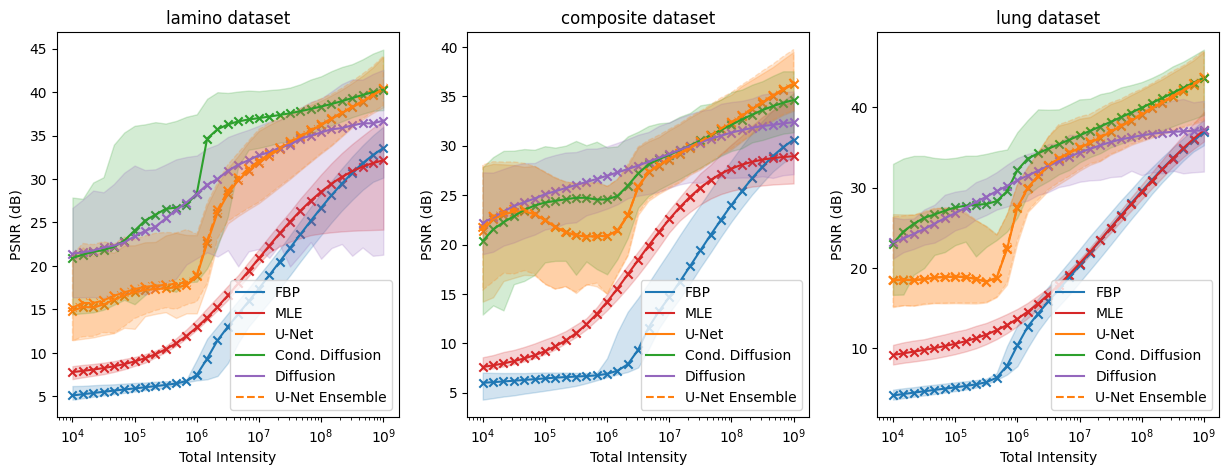

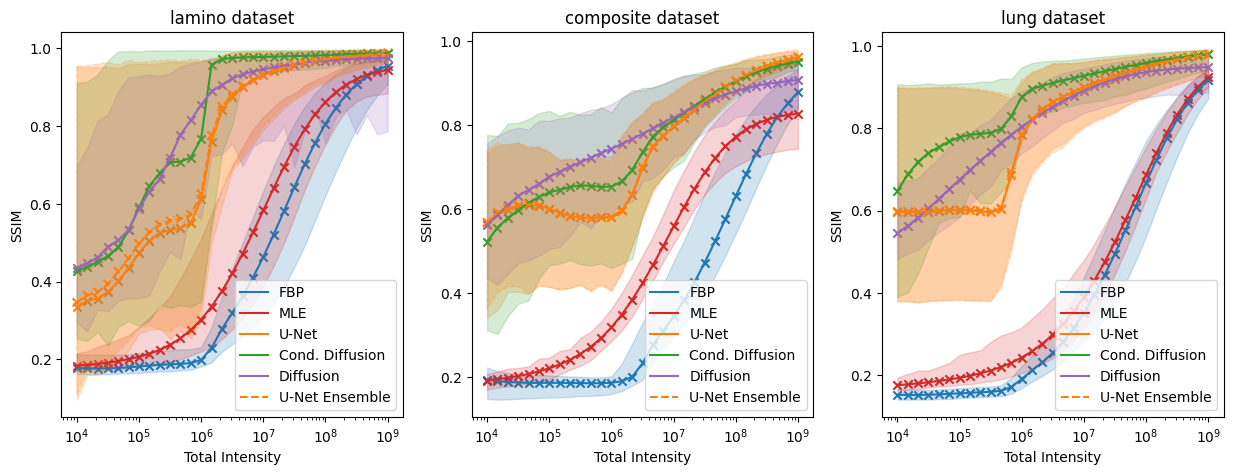

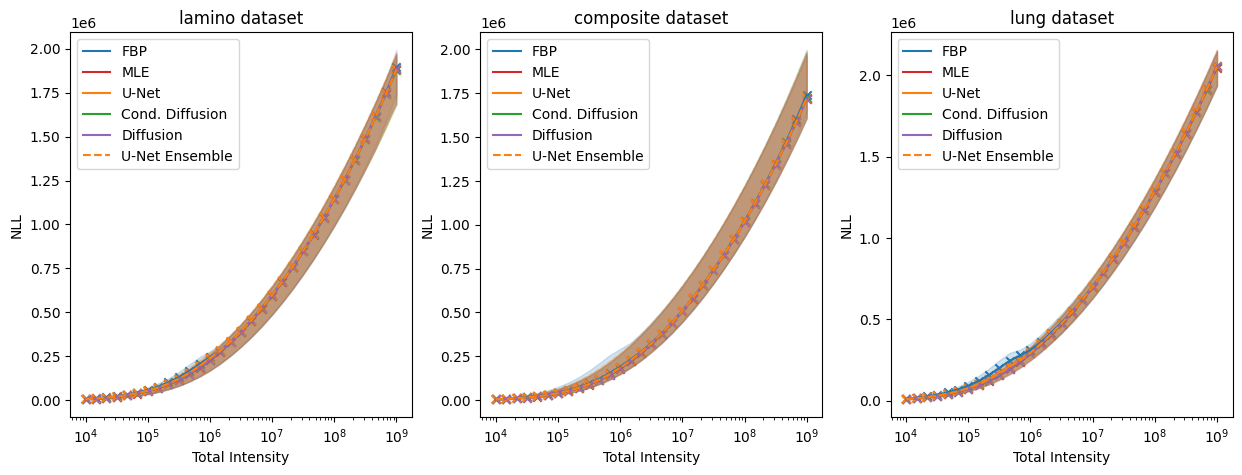

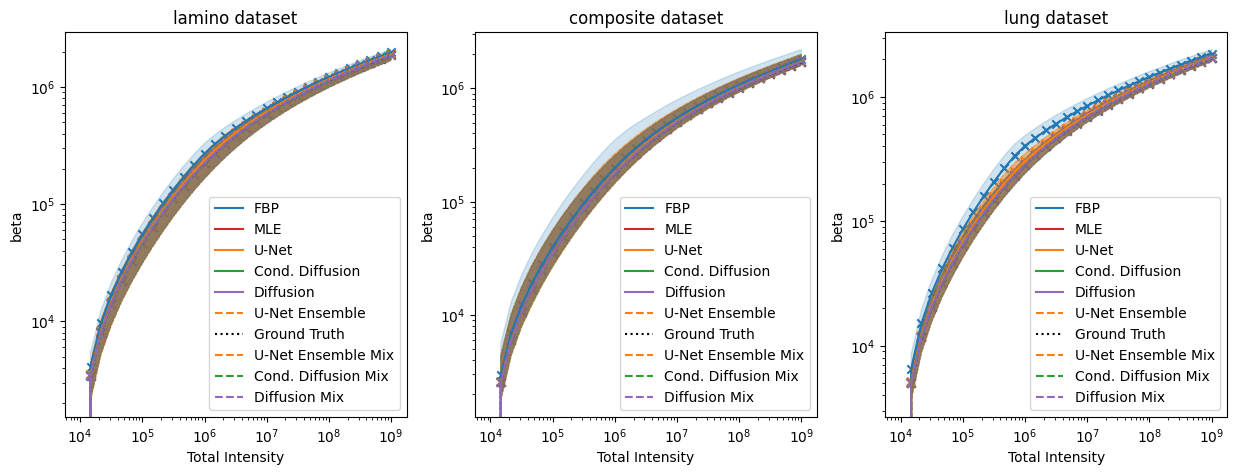

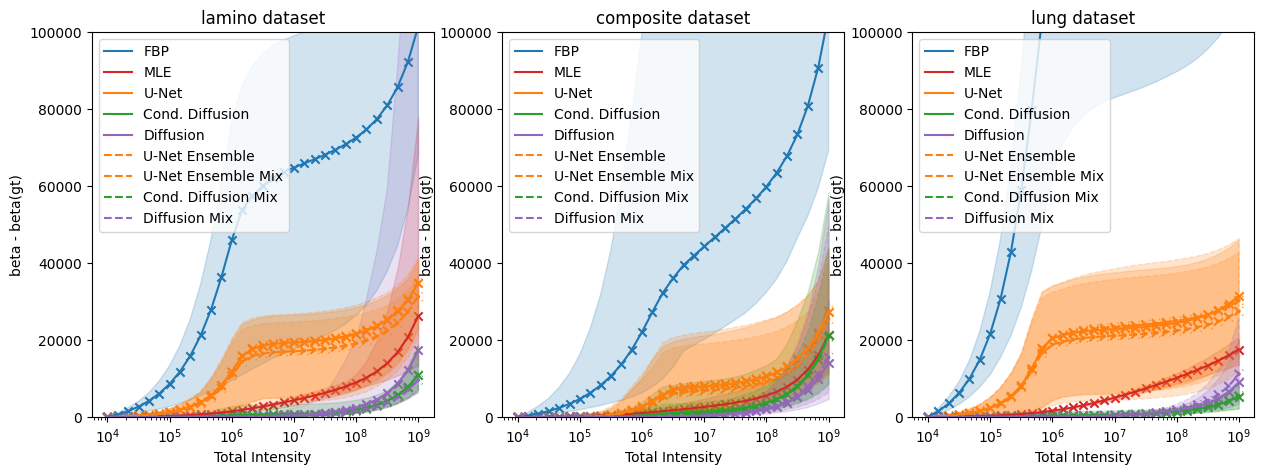

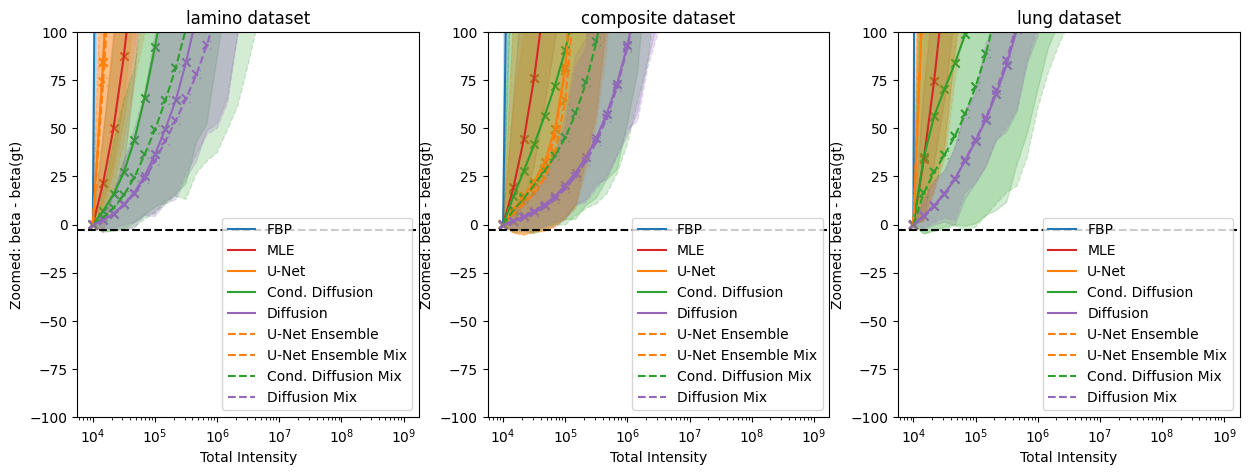

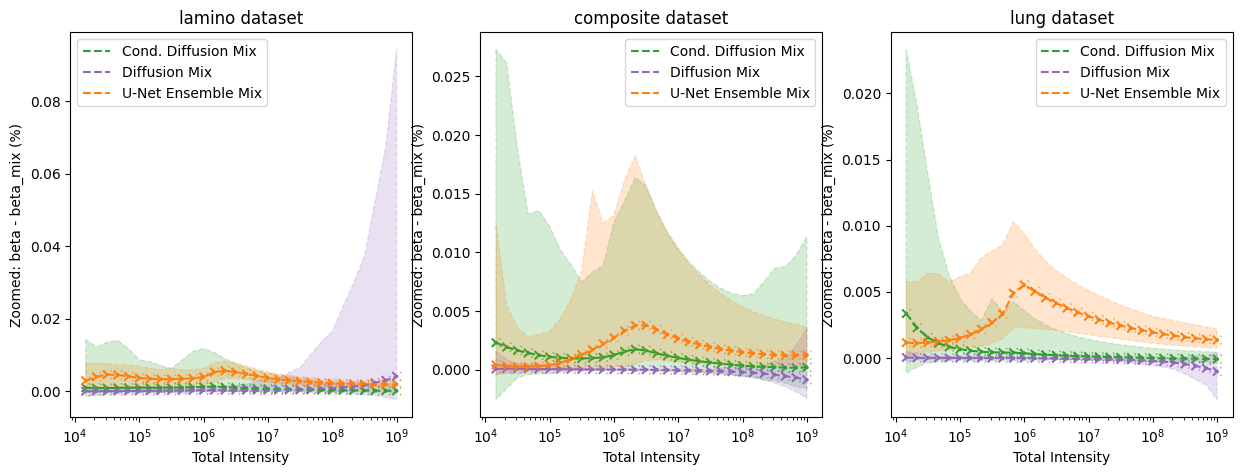

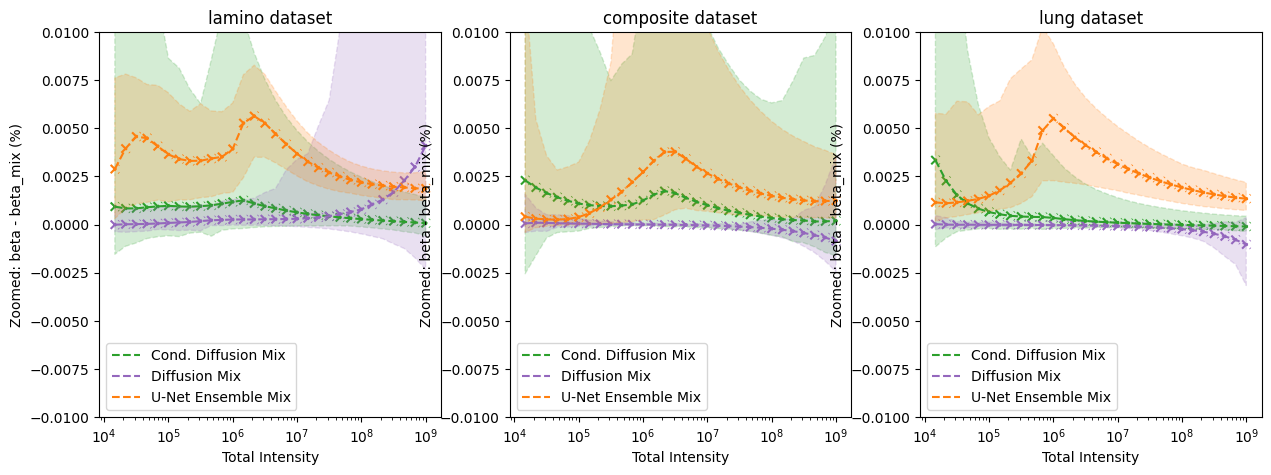

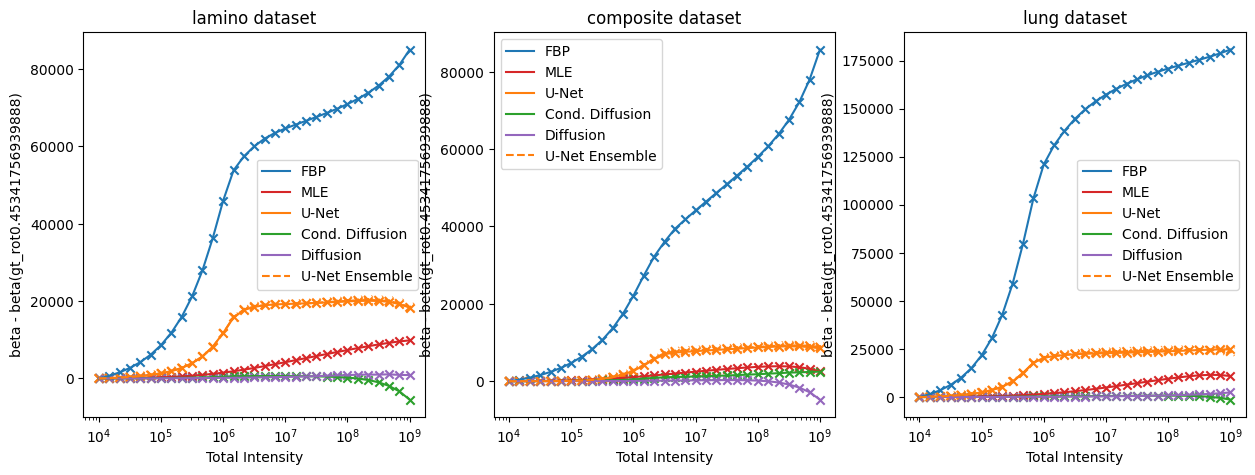

In [25]:

from cv2 import line


def plot_psnr(ax, dataset, model, metric='psnr', plot_range=True, gt_rotation=0, line_kwargs=None, match_attrs=None, _attrs=None, _datasets=None):
    if _attrs is None:
        _attrs = attrs
    if _datasets is None:
        _datasets = datasets
    if line_kwargs is None:
        line_kwargs = LINE_KWARGS[model]
    if match_attrs is None and model in MATCH_ATTRS:
        match_attrs = MATCH_ATTRS[model]

    if model == 'gt':
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, samples=True, match_attrs=match_attrs)
        ds = ds.sel(rotation=gt_rotation)
    elif model == 'cond_diffusion':
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, aggregate_seeds=True, match_attrs=match_attrs)
    else:
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, match_attrs=match_attrs)


    if metric in ['psnr', 'nll', 'beta', 'beta_mix', 'ssim'] or metric.startswith('uq_'):
        y = ds[metric]
    elif metric == 'beta_diff':
        ds_gt = find_experiment(_attrs, _datasets, dataset, 'gt', samples=True)[0].sel(rotation=gt_rotation)
        y = ds["beta"] - ds_gt["beta"]
    elif metric == 'beta_mix_diff':
        ds_gt = find_experiment(_attrs, _datasets, dataset, 'gt', samples=True)[0].sel(rotation=gt_rotation)
        y = ds["beta_mix"] - ds_gt["beta"]
    elif metric == 'beta - beta_mix':
        y = (ds["beta"] - ds["beta_mix"]) / ds["beta"]
    elif metric == 'beta_diff_fbp':
        ds_fbp, _ = find_experiment(_attrs, _datasets, dataset, 'fbp')
        y = ds["beta"] - ds_fbp["beta"]
    else:
        raise ValueError(f"Unknown metric {metric}")
    
    y_mean = y.mean(dim=['index', 'seed']).squeeze().values
    y_min = y.min(dim=['index', 'seed']).squeeze().values
    y_max = y.max(dim=['index', 'seed']).squeeze().values
    
    intensity = ds.sel(seed=0, index=0)['intensity']
    x = intensity.cumsum()

    if 'mix' in metric:
        line_kwargs = line_kwargs.copy()
        line_kwargs['linestyle'] = '--'
        line_kwargs['label'] = line_kwargs['label'] + ' Mix'

    plot_kwargs_without_label = {k: v for k, v in line_kwargs.items() if k != 'label'}

    ax.plot(x, y_mean, **line_kwargs)
    ax.scatter(x, y_mean, marker='x', **plot_kwargs_without_label)
    if plot_range:
        # Remove 'label' from kwargs for fill_between to avoid duplicate legend entries
        ax.fill_between(x, y_min, y_max, alpha=0.2, **plot_kwargs_without_label)
    ax.set_xscale("log")
    ax.set_title(f"{dataset} dataset")

rotation = find_experiment(attrs, datasets, 'lamino', 'gt', samples=True)[0]['rotation'].values

models = ['fbp', 'mle', 'unet', 'cond_diffusion', 'diffusion', 'unet_ensemble']
mixing_models = ['unet_ensemble', 'cond_diffusion', 'diffusion']
# psnr
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='psnr')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("PSNR (dB)")
    ax.legend()

# ssim
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='ssim')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("SSIM")
    ax.legend()


# nll
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='nll')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("NLL")
    ax.legend()

# beta
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models + ['gt']:
        plot_psnr(ax, dataset, model, metric='beta')

    for model in mixing_models:
        plot_psnr(ax, dataset, model, metric='beta_mix')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("beta")
    ax.set_yscale('log')
    ax.legend()


delta = 0.05
# beta diff
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='beta_diff')
    for model in mixing_models:
        plot_psnr(ax, dataset, model, metric='beta_mix_diff')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("beta - beta(gt)")
    # ax.axhline(-np.log(1/delta), color='k')
    ax.set_ylim([0, 100000])
    ax.legend()

# beta zoomed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='beta_diff')
    for model in mixing_models:
        plot_psnr(ax, dataset, model, metric='beta_mix_diff')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta(gt)")
    ax.set_ylim([-100, 100])
    ax.axhline(-np.log(1/delta), color='k', linestyle='--')
    ax.legend()


# beta - beta_mix
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in ['cond_diffusion', 'diffusion', 'unet_ensemble']:
        plot_psnr(ax, dataset, model, metric='beta - beta_mix')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta_mix (%)")
    ax.legend()

# beta - beta_mix (zoomed)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in ['cond_diffusion', 'diffusion', 'unet_ensemble']:
        plot_psnr(ax, dataset, model, metric='beta - beta_mix')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta_mix (%)")
    ax.legend()
    ax.set_ylim([-0.01, 0.01])



# # beta diff fbp
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='beta_diff_fbp')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("beta - beta(fbp)")
#     ax.legend()

# beta diff with rotation 1.0
gt_rotation = rotation[3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in models:
        plot_psnr(ax, dataset, model, metric='beta_diff', plot_range=False, gt_rotation=gt_rotation)
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel(f"beta - beta(gt_rot{gt_rotation})")
    ax.legend()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    ds_gt = find_experiment(dataset, 'gt', samples=False)[0]
    ds_beta = find_experiment(dataset, 'cond_diffusion', samples=False, aggregate_seeds=True)[0]


    deltas = np.linspace(0.001, 1, 10)
    deltas = np.logspace(-4, 0)
    coverages = []
    for delta in deltas:
        coverage = (((ds_gt['beta'] - ds_beta['beta_mix']).sel(step=slice(1, None))).max(dim='step') >= 1 * np.log(1./delta)).mean(dim=('dataset', 'index', 'seed'))
        # break
        coverages.append(coverage)
    ax.plot(deltas, coverages, marker='x')
    ax.plot(deltas, deltas, color='k', linestyle='--')
    ax.set_xlabel('delta')
    ax.set_ylabel('empirical violation rate')
    ax.set_title(f"{dataset}")
    ax.set_xscale('log')
    ax.set_yscale('log')

# (ds_gt['beta'] - ds_beta['beta_mix']).max(dim=('dataset', 'index', 'seed')).plot()
# plt.axhline(np.log(1/delta), color='k', linestyle='--')

In [ ]:
import numpy as np

def calibrate_and_compute_rates(ds_gt, ds_beta, deltas):
    """
    Computes calibrated violation rates by estimating the empirical slope 
    offset and applying it to the threshold.
    """
    # 1. Pre-compute the statistic (max deviation over steps)
    #    Doing this once outside the loop saves significant time.
    diff = (ds_gt['beta'] - ds_beta['beta_mix']).sel(step=slice(1, None))
    # Shape: (dataset, index, seed)
    stat = diff.max(dim='step') 
    
    # 2. Estimate the Slope 's'
    #    We check the violation rate at threshold = 0 (which corresponds to delta=1.0)
    #    Theoretical rate should be 1.0. Empirical rate is 's'.
    #    This captures the vertical offset in the log-probability space.
    zero_threshold_rate = (stat >= 0).mean(dim=('dataset', 'index', 'seed'))
    slope_correction = float(zero_threshold_rate)
    
    print(f"Calibration Factor (Slope): {slope_correction:.4f}")
    
    # 3. Compute Calibrated Rates
    calibrated_rates = []
    
    for delta in deltas:
        # Apply correction: threshold = log( s / delta )
        # This lowers the threshold exactly enough to boost the rate by 1/s
        
        # Handle edge case where delta > slope_correction (threshold becomes negative)
        # This is valid math, but ensures we don't log(0)
        safe_ratio = slope_correction / delta
        
        thresh_calibrated = np.log(safe_ratio)
        
        # Calculate rate
        rate = (stat >= thresh_calibrated).mean(dim=('dataset', 'index', 'seed'))
        calibrated_rates.append(rate)
        
    return calibrated_rates, slope_correction

# --- Usage ---
deltas = np.logspace(-3, 0) # Your deltas
calibrated_coverages, s = calibrate_and_compute_rates(ds_gt, ds_beta, deltas)

# Now 'calibrated_coverages' should match 'deltas' nearly 1:1

In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# prepare M (shape: samples)
M = (((ds_gt['beta'] - ds_beta['beta_mix'])
      .sel(step=slice(1, None)))
     .max(dim='step')) \
     .stack(samples=('dataset','index','seed')) \
     .values.ravel()  # 1D array of sample statistics

deltas = np.logspace(-3, 0, 50)

# 1) exact per-delta calibration (nonparametric)
quantiles = np.quantile(M, 1.0 - deltas)             # T_cal(delta)
viol_emp_exact = np.array([(M >= q).mean() for q in quantiles])  # should ~ deltas

# 2) global scalar multiplier
nominal_T = np.log(1.0 / deltas)
s_vals = quantiles / nominal_T                       # per-delta s(delta)
s_global = np.median(s_vals)                         # or np.mean(s_vals)
viol_emp_scaled = np.array([(M >= s_global * np.log(1.0 / d)).mean() for d in deltas])

# 3) linear fit: q ≈ a + b * log(1/d)
X = np.vstack([np.ones_like(nominal_T), nominal_T]).T
coeffs = np.linalg.lstsq(X, quantiles, rcond=None)[0]  # [a, b]
T_fit = coeffs[0] + coeffs[1] * nominal_T
viol_emp_fit = np.array([(M >= t).mean() for t in T_fit])

# Plot comparison
plt.figure(figsize=(5,4))
plt.plot(deltas, deltas, '--', label='nominal (y = delta)')
plt.plot(deltas, (M >= nominal_T[:,None]).mean(axis=1), 'x-', label='empirical uncalibrated')  # alternative compute if needed
plt.plot(deltas, viol_emp_exact, 'o-', label='calibrated (per-delta)')
plt.plot(deltas, viol_emp_scaled, 's-', label=f'calibrated (scale s={s_global:.3f})')
plt.plot(deltas, viol_emp_fit, 'd-', label='calibrated (linear fit)')
plt.xscale('log')
plt.xlabel('delta')
plt.ylabel('empirical violation rate')
plt.legend()
plt.show()


NameError: name 'ds_gt' is not defined

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 10 experiments for model cond_diffusion and dataset composite.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')
/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


Aggregation 10 experiments for model cond_diffusion and dataset lung.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


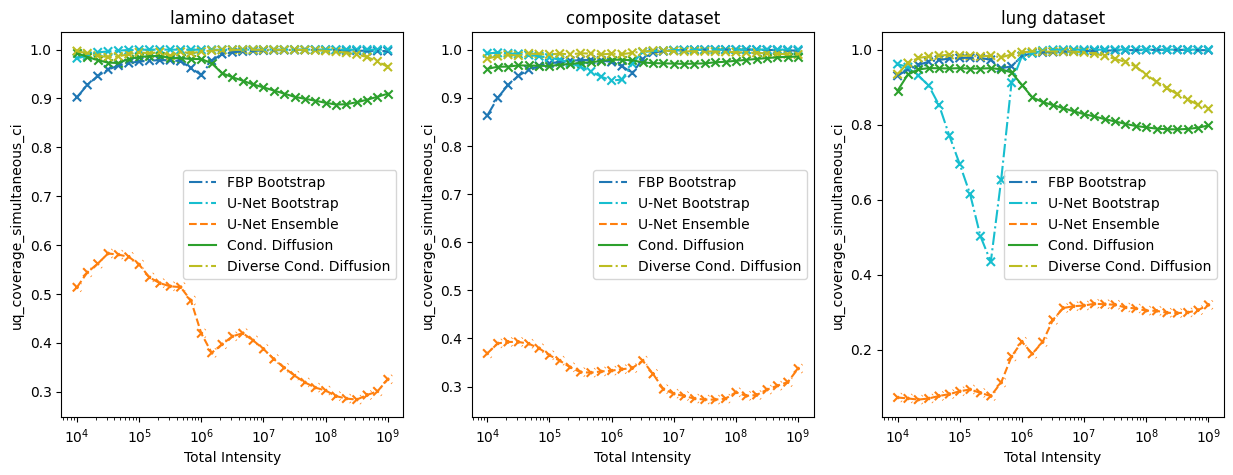

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 10 experiments for model cond_diffusion and dataset composite.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')
/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


Aggregation 10 experiments for model cond_diffusion and dataset lung.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


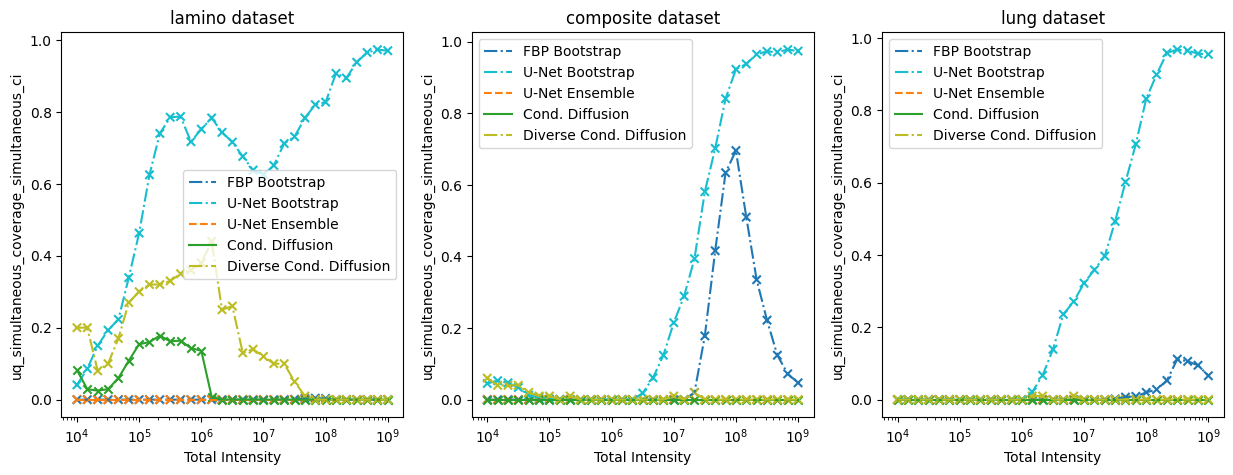

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 10 experiments for model cond_diffusion and dataset composite.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')
/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


Aggregation 10 experiments for model cond_diffusion and dataset lung.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


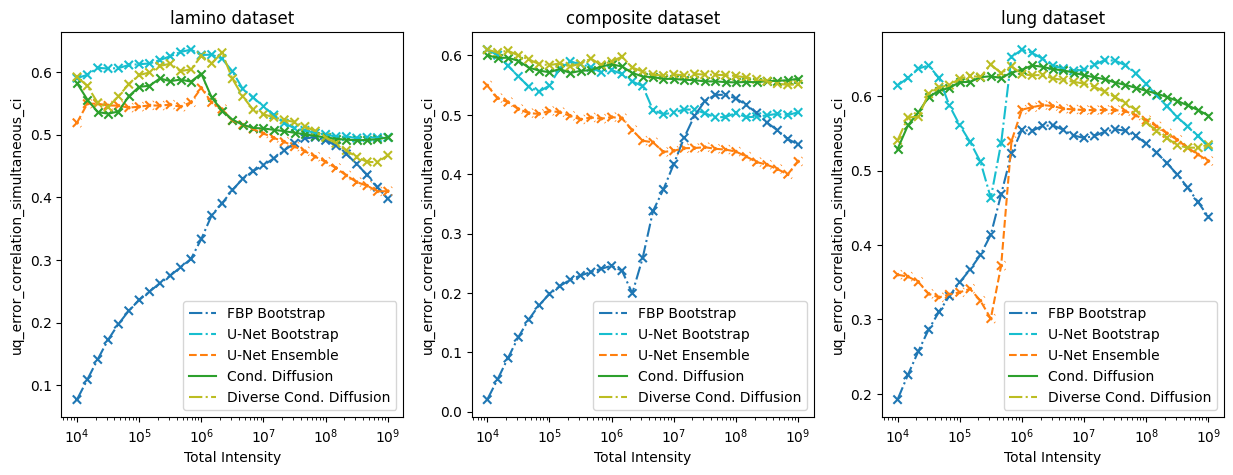

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 10 experiments for model cond_diffusion and dataset composite.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')
/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


Aggregation 10 experiments for model cond_diffusion and dataset lung.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


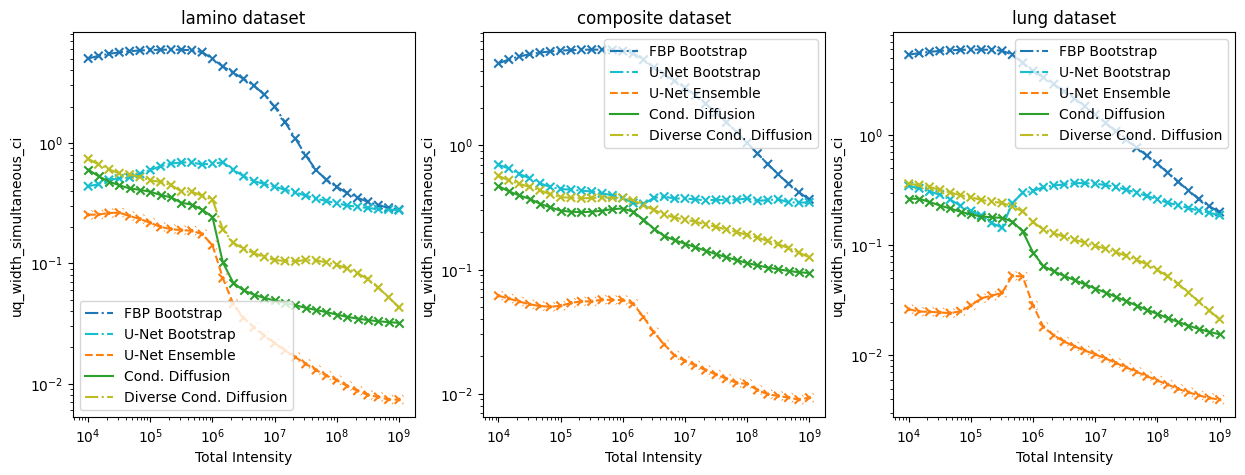

Aggregation 10 experiments for model cond_diffusion and dataset lamino.
Aggregation 10 experiments for model cond_diffusion and dataset composite.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')
/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


Aggregation 10 experiments for model cond_diffusion and dataset lung.


/tmp/ipykernel_7270/3332832948.py:53: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(all_ds, dim='seed')


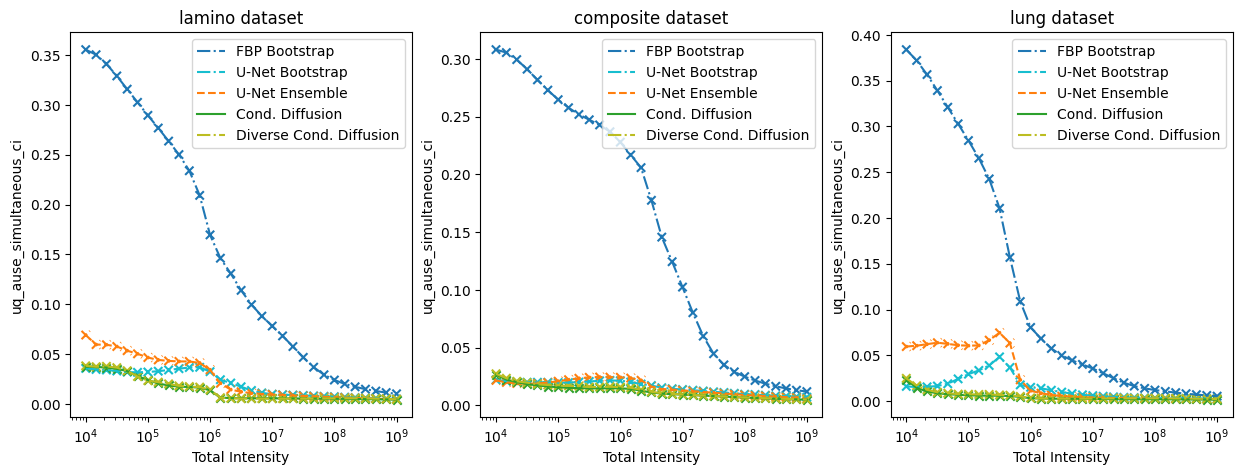

In [15]:
# uq_coverage_gaussian_0.05

for uq_metric in [
    'uq_coverage', 
    'uq_simultaneous_coverage', 
    'uq_error_correlation',
    'uq_width',
    'uq_ause'
    # 'uq_coverage_basic_0.05', 
    # 'uq_error_correlation_basic_0.05'
    ]:
    for ci_name in [
        # 'gaussian', 
        # 'gaussian_conservative_ci', 
        'simultaneous_ci'
        ]:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
            for model in ['fbp_bootstrap', 'unet_bootstrap', 'unet_ensemble', 'cond_diffusion', 'diverse_cond_diffusion']:
                plot_psnr(ax, dataset, model, metric=f"{uq_metric}_{ci_name}_0.05", plot_range=False)
            ax.set_xlabel("Total Intensity")
            ax.set_ylabel(f"{uq_metric}_{ci_name}")
            ax.legend()
            if uq_metric == 'uq_width':
                ax.set_yscale('log')
        plt.show()

## Diffusion Ablation

In [6]:
ablation_datasets, ablation_attrs = read_dataset("../results-final/diffusion-ablation/", "../results-final/2026-01-24/")
print_stats(ablation_attrs)

1e+04 to 1e+09: 174 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,38,38,38
diffusion,4,6,8
diverse_cond_diffusion,6,6,6
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1


In [15]:
ablation_attrs['seeds'].unique()

array(['[0]', '[1]', '[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]', '[7]', '[5]',
       '[6]', '[2]', '[3]', '[9]', '[4]', '[8]'], dtype=object)

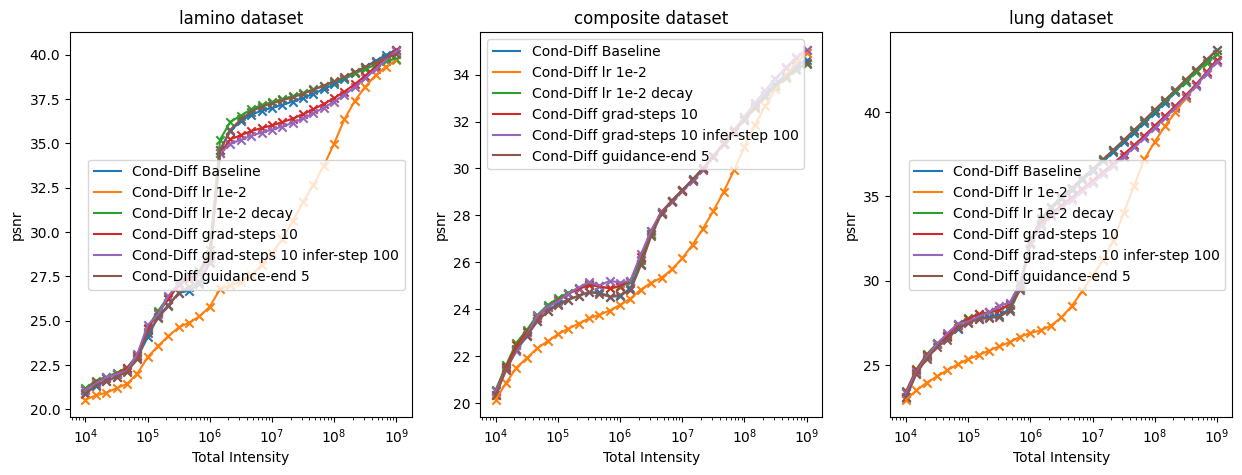

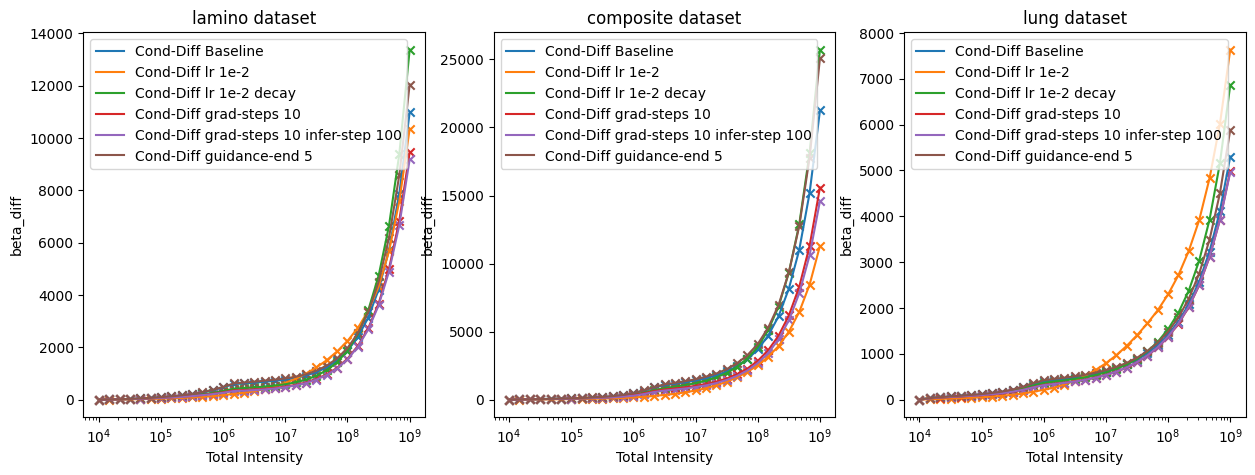

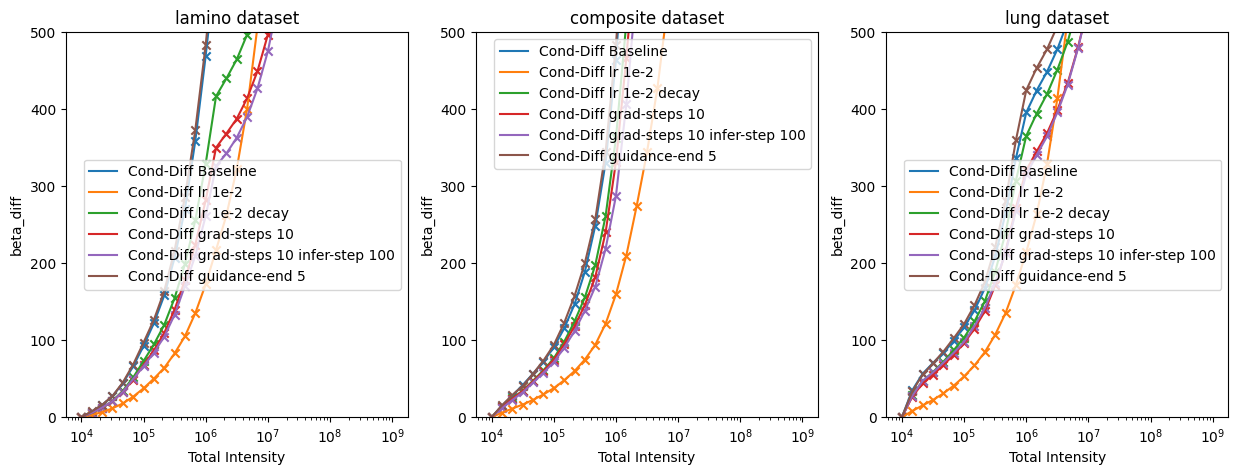

In [30]:
# psnr
for metric in ['psnr', 'beta_diff', 'beta_diff_zoomed']:
    zoomed = metric.endswith('zoomed')
    if zoomed:
        metric = 'beta_diff'
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff Baseline', 'color': 'C0'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff lr 1e-2', 'color': 'C1'}, 
                match_attrs={'guidance_lr' : 1e-2, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff lr 1e-2 decay', 'color': 'C2'}, 
                match_attrs={'guidance_lr' : 1e-2, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : True, 'guidance_end' : 0})
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff grad-steps 10', 'color': 'C3'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff grad-steps 10 infer-step 100', 'color': 'C4'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10, 'diffusion_num_inference_steps' : 100, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_psnr(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff guidance-end 5', 'color': 'C5'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 5})
        ax.set_xlabel("Total Intensity")
        ax.set_ylabel(metric)
        ax.legend()

        if zoomed:
            ax.set_ylim([0, 500])

# # ssim
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='ssim')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("SSIM")
#     ax.legend()


# # nll
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='nll')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("NLL")
#     ax.legend()

# # beta
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models + ['gt']:
#         plot_psnr(ax, dataset, model, metric='beta')

#     for model in mixing_models:
#         plot_psnr(ax, dataset, model, metric='beta_mix')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("beta")
#     ax.set_yscale('log')
#     ax.legend()


# delta = 0.05
# # beta diff
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='beta_diff')
#     for model in mixing_models:
#         plot_psnr(ax, dataset, model, metric='beta_mix_diff')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("beta - beta(gt)")
#     # ax.axhline(-np.log(1/delta), color='k')
#     ax.set_ylim([0, 100000])
#     ax.legend()

# # beta zoomed
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='beta_diff')
#     for model in mixing_models:
#         plot_psnr(ax, dataset, model, metric='beta_mix_diff')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("Zoomed: beta - beta(gt)")
#     ax.set_ylim([-100, 100])
#     ax.axhline(-np.log(1/delta), color='k', linestyle='--')
#     ax.legend()


# # beta - beta_mix
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in ['cond_diffusion', 'diffusion', 'unet_ensemble']:
#         plot_psnr(ax, dataset, model, metric='beta - beta_mix')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("Zoomed: beta - beta_mix (%)")
#     ax.legend()

# # beta - beta_mix (zoomed)
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in ['cond_diffusion', 'diffusion', 'unet_ensemble']:
#         plot_psnr(ax, dataset, model, metric='beta - beta_mix')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("Zoomed: beta - beta_mix (%)")
#     ax.legend()
#     ax.set_ylim([-0.01, 0.01])

In [ ]:
ds = find_experiment('lamino', 'unet_ensemble')[0]

var_names = list(ds.data_vars.keys())
var_names = [name for name in var_names if 'gaussian' in name]
print('\'\n\''.join(var_names))
ds.compute()

In [ ]:
find_experiment('lamino', 'gt')[0]

In [ ]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from typing import Any
import argparse
import os

from uqct.datasets.utils import get_dataset
from uqct.metrics import get_metrics
from uqct.ct import fbp, nll, Experiment, Tomogram, anscombe_transform, radon, sinogram_from_counts, poisson, sample_observations, circular_mask

import torch.nn.functional as F
import astra

from uqct.models.diffusion import load_unet as load_diffusion_unet
from diffusers.models.unets.unet_2d import UNet2DModel
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from uqct.models.guided_diffusion import GradientGuidance, GuidedDiffusionPipeline
import xarray as xr

from uqct.training.unet import N_BINS_HR
from typing import NamedTuple


from uqct.evaluation.eval_dense import schedule_exponential, schedule_uniform, ObservationDataset, fbp_recon

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Args(NamedTuple):
    model: str = "fbp"  # "unet", "diffusion", "cond_diffusion"
    dataset: str = "lung"
    num_images: int = 10
    batch_size: int = 2
    seeds: list[int] = [0]
    schedule: str = "exponential"  # "uniform" or "exponential"
    total_intensity: float = 1e9
    num_steps: int = 10
    init_fraction: float = None
    initial_intensity: float = 1e7
    base: float = 1.1
    num_samples: int = 5
    diffusion_num_inference_steps: int = 100
    guidance_end: int = 10
    guidance_num_gradient_steps: int = 10
    guidance_lr: float = 1e-3

dataset = "lamino"
model = "cond_diffusion"
idx = 0
seed = 0

ds, _ = find_experiment(dataset, model)

args = Args(
    model=model,
    seeds=[seed], 
    dataset=dataset, 
    initial_intensity=float(ds.attrs['initial_intensity']), 
    total_intensity=float(ds.attrs['total_intensity']), 
    num_steps=int(ds.attrs['num_steps']),
    diffusion_num_inference_steps=int(ds.attrs['diffusion_num_inference_steps']),
    guidance_end=int(ds.attrs['guidance_end']),
    guidance_num_gradient_steps=int(ds.attrs['guidance_num_gradient_steps']),
    guidance_lr=float(ds.attrs['guidance_lr']),
    )
print(args)
print(f"{args.total_intensity:e}")
print(f"{args.initial_intensity:e}")

# get dataset
_ , test_set = get_dataset(args.dataset, True)
if args.num_images is not None:
    test_set = torch.utils.data.Subset(test_set, list(range(args.num_images)))

# set up observation parameters
num_angles = 200
angles = torch.from_numpy(np.linspace(0, 180, num_angles, endpoint=False)).float().to(device)
if args.schedule == "uniform":
    schedule = schedule_uniform(
        args.total_intensity, args.num_steps, init_fraction=args.init_fraction, device=device
    )
elif args.schedule == "exponential":
    schedule = schedule_exponential(
        args.total_intensity, args.num_steps, initial_intensity=args.initial_intensity, device=device
    )
total_intensities = schedule.clone()
print(total_intensities.cumsum(dim=0))
schedule = schedule.reshape(-1, 1, 1, 1).expand(-1, 1, len(angles), 1) / len(angles) / 256
# schedule_steps = np.arange(schedule.shape[1])

# set up observation dataset and dataloader
obs_dataset = ObservationDataset(test_set, seeds=args.seeds, intensities=schedule, angles=angles)
# obs_dataloader = torch.utils.data.DataLoader(
#     obs_dataset, batch_size=args.batch_size, shuffle=False, num_workers=0
# )

_, _, image, data = obs_dataset.get(idx, seed)


In [ ]:
image_lr = F.interpolate(image.unsqueeze(0), size=(128, 128), mode='area').squeeze(0)
image_lr

In [ ]:
mask = circular_mask(image_lr.shape[-1], device=image_lr.device)
image_lr_masked = image_lr * mask

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3))
ax1.imshow(image.squeeze().cpu(), cmap='gray')
ax2.imshow(image_lr.squeeze().cpu(), cmap='gray')
ax3.imshow(image_lr_masked.squeeze().cpu(), cmap='gray')
ax4.imshow( (image_lr - image_lr_masked).squeeze().cpu(), cmap='viridis')

In [ ]:
print(total_intensities.cumsum(dim=0))

In [ ]:
from diffusers.models.unets.unet_2d import UNet2DModel
from uqct.evaluation.eval_dense import UNetRecon, load_unet, CondDiffusionRecon
from uqct.models.diffusion import load_unet as load_diffusion_unet


print(model)

if model == "fbp":
    recon = fbp_recon
elif model == "unet":
    ckpt_path = Path(f'/mydata/chip/shared/checkpoints/uqct/unet_dense/unet_dense_128_{args.dataset}_0.pt')
    print(f"Loading UNet checkpoint from {ckpt_path}")
    unet = load_unet(ckpt_path, sparse=False).to(device).eval()
    recon = UNetRecon(unet)
elif model == "cond_diffusion":
    ckpt_path = Path(f"/mydata/chip/shared/checkpoints/uqct/diffusion/ddpm_conditional_128_{args.dataset}.pt")
    unet_diffusion = load_diffusion_unet(ckpt_path, cond=True).to(device).eval()
    scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
    print(args.num_samples)
    recon = CondDiffusionRecon(
        unet_diffusion,
        scheduler,
        num_samples=args.num_samples,
        num_inference_steps=args.diffusion_num_inference_steps,
        guidance_start=1000,
        guidance_end=args.guidance_end,
        guidance_num_gradient_steps=args.guidance_num_gradient_steps,
        guidance_lr=args.guidance_lr
    )

In [ ]:

steps = [1, 2, 3, 4, 8, 10]

recon = CondDiffusionRecon(
    unet_diffusion,
    scheduler,
    num_samples=args.num_samples,
    num_inference_steps=args.diffusion_num_inference_steps,
    guidance_start=1000,
    guidance_end=args.guidance_end,
    guidance_num_gradient_steps=args.guidance_num_gradient_steps,
    # guidance_num_gradient_steps=1,
    guidance_lr=args.guidance_lr
    # guidance_lr=1e-8
)

with torch.no_grad():
    # add batch dimension and sum total intensity and observations
    data_cumsum = data.unsqueeze(0).cumsum(dim=1)  
    schedule_cumsum = schedule.unsqueeze(0).cumsum(dim=1)
    # total_intensities = schedule_cumsum.expand(data_cumsum.shape).sum(dim=(-1, -2))
    # print(data_cumsum.shape, schedule_cumsum.shape)
    with torch.no_grad():
        pred = [recon(data_cumsum[:, i], schedule_cumsum[:, i], angles) for i in tqdm(steps)]
        print(pred[0].shape)
        if args.model in ["diffusion", "cond_diffusion"]:
            pred = torch.stack(pred, dim=2)
        else:
            pred = torch.stack(pred, dim=1)
pred  # shape 11, 1, 128, 128 for (num_steps, channels, height, width)
# pred_incr = pred[0, 1:]
# pred_incr

In [ ]:
fig, axes = plt.subplots(len(steps), len(pred), figsize=(2 * len(pred), 2 * len(steps)))


for j in range(len(steps)):
    for i in range(len(pred)):
        axes[j, i].imshow(pred[i, 0, j].squeeze().cpu(), cmap='gray')
        axes[j, i].set_title(f"Step {steps[i]}")
        axes[j, i].axis('off')

In [ ]:
img_pred = pred[0,0,-1]
cum_nll_pred = nll(img_pred, data, schedule, angles).sum(dim=[-1, -2, -3])[1:].cumsum(dim=0).cpu()
beta = ds.sel(seed=seed, index=idx)['beta'].squeeze().values

plt.plot(cum_nll_pred, label='predicted beta')
plt.plot(beta[1:], label='true beta')
plt.legend()

In [ ]:
torch.arange(10)[:1]

In [ ]:
def guidance_loss_beta(counts, intensities, angles, beta, data_steps, schedule_steps, l=5.):
    """
    Define a loss function for the diffusion model.
    This can be used to guide the diffusion process.
    """
    data_shape = counts.shape[:-2]
    circle_mask = circular_mask(counts.shape[-1], device=counts.device)
    def loss_fn(image):
        img_shape = image.shape[-2:]
        image = image.view(-1, *data_shape, *img_shape)
        image = ((image + 1.0)/2).clip(0, 1)
        image = image * circle_mask

        # note batch dims are a bit mixed up here: image does not have a step dimension, data_step has a batch dimension but not a sampling dimension
        # if we want both batch and step dims, we need to expand image
        # full_nll = nll(image, data_steps, schedule_steps, angles, l=l).sum(dim=[-1,-2, -3])

        step_nll =  nll(image, data_steps, schedule_steps, angles, l=l).sum(dim=[-1,-2, -3])
        first_step_nll = step_nll[:,0]
        remaining_step_nll = step_nll[:,1:]
        beta_loss = remaining_step_nll.sum(dim=-1)
        loss = torch.abs(beta_loss - beta)# + first_step_nll
        # print(beta_loss - beta)
        return loss.sum()  # remaining dimensions (samples, batch, steps)
    return loss_fn


recon_beta = CondDiffusionRecon(
    unet_diffusion,
    scheduler,
    num_samples=args.num_samples,
    num_inference_steps=args.diffusion_num_inference_steps,
    guidance_start=1000,
    guidance_end=0,
    guidance_num_gradient_steps=50,
    guidance_lr=1e-3,
    guidance_loss=guidance_loss_beta
)

steps = [1, 2, 3, 4, 5, 10, 20, 30]

with torch.no_grad():
    # add batch dimension and sum total intensity and observations
    data_cumsum = data.unsqueeze(0).cumsum(dim=1)  
    schedule_cumsum = schedule.unsqueeze(0).cumsum(dim=1)
    data_steps = data.unsqueeze(0)
    schedule_steps = schedule.unsqueeze(0)
    beta = beta = ds["beta"].sel(index=0, seed=0).squeeze().values
    beta = torch.tensor(beta, device=device, dtype=torch.float32)
    print(beta.shape)
    # total_intensities = schedule_cumsum.expand(data_cumsum.shape).sum(dim=(-1, -2))
    # print(data_cumsum.shape, schedule_cumsum.shape)
    with torch.no_grad():
        pred_beta = [recon_beta(data_cumsum[:, i], schedule_cumsum[:, i], angles, beta=beta[i], data_steps=data_steps[:, :i+1], schedule_steps=schedule_steps[:, :i+1]) for i in tqdm(steps)]
        print(pred_beta[0].shape)
        if args.model in ["diffusion", "cond_diffusion"]:
            pred_beta = torch.stack(pred_beta, dim=2)
        else:
            pred_beta = torch.stack(pred_beta, dim=1)

In [ ]:
pred_beta.unsqueeze(3), data, pred

In [ ]:
beta = ds["beta"].sel(index=0, seed=0).squeeze().values
beta = torch.tensor(beta, device=device, dtype=torch.float32)
x = total_intensities.cumsum(dim=0)[steps].squeeze().cpu()
x = [*range(len(steps))]


nll_cum_beta = nll(pred_beta.unsqueeze(3), data.unsqueeze(0), schedule, angles).sum(dim=[-1, -2, -3])[:, :, :, 1:].cumsum(dim=-1)
idx = torch.tensor(steps, dtype=torch.long, device=nll_cum_beta.device) - 1  # (8,)
idx = idx.view(1, 1, -1, 1).expand(nll_cum_beta.shape[0], nll_cum_beta.shape[1], nll_cum_beta.shape[2], 1)  # (5, 1, 8, 1)
nll_cum_beta = torch.gather(nll_cum_beta, dim=3, index=idx).squeeze(3)  # (5, 1, 8)
print(nll_cum_beta.shape)

nll_cum = nll(pred.unsqueeze(3), data.unsqueeze(0), schedule, angles).sum(dim=[-1, -2, -3])[:, :, :, 1:].cumsum(dim=-1)
idx = torch.tensor(steps, dtype=torch.long, device=nll_cum.device) - 1  # (8,)
idx = idx.view(1, 1, -1, 1).expand(nll_cum.shape[0], nll_cum.shape[1], nll_cum.shape[2], 1)  # (5, 1, 8, 1)
nll_cum = torch.gather(nll_cum, dim=3, index=idx).squeeze(3)  # (5, 1, 8)
# print(nll_cum)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(x, (nll_cum_beta).squeeze().T.cpu().numpy())
plt.gca().set_prop_cycle(None)
ax1.plot(x, (nll_cum).squeeze().T.cpu().numpy(), linestyle=':')
ax1.plot(x, (beta[steps]).squeeze().T.cpu().numpy(), linestyle='--', color='black')

# ax2.plot(((nll_cum_beta - beta[1:])/beta[1:]).squeeze().T.cpu().numpy())
ax2.plot(x, ((nll_cum_beta - beta[steps])).squeeze().T.cpu().numpy())
plt.gca().set_prop_cycle(None)
ax2.plot(x, ((nll_cum - beta[steps])).squeeze().T.cpu().numpy(), linestyle=':')

In [ ]:
total_intensities.squeeze().cumsum(dim=0)

In [ ]:
print("test")

In [ ]:

_num_samples = 3
fig, axes = plt.subplots(len(steps), 2 * _num_samples + 4, figsize=((2 * _num_samples + 4)* 3, 3 * len(steps)))
for i, (step_i, axs) in enumerate(zip(range(len(steps)), axes)):
    step = steps[step_i]
    _intensity = total_intensities[:step].sum().item()
    for j in range(_num_samples):
        axs[j].imshow(pred[j, 0, step_i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axs[j].set_title(f"Step {step} Sample {j}", fontsize=11)
        axs[j].axis('off')

        axs[j + _num_samples].imshow(pred_beta[j, 0, step_i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axs[j + _num_samples].set_title(f"Step {step} Sample {j} (beta)", fontsize=11)
        axs[j + _num_samples].axis('off')

    std_image = torch.std(pred[:, 0, step_i, 0], dim=0)
    std_image_beta = torch.std(pred_beta[:, 0, step_i, 0], dim=0)
    mean_std_image = torch.mean(std_image)
    mean_std_image_beta = torch.mean(std_image_beta)
    mean_image = torch.mean(pred[:, 0, step_i, 0], dim=0)
    abs_error = torch.abs(mean_image - image_lr[0])

    axs[-4].imshow(std_image_beta.cpu(), cmap='hot')
    axs[-4].set_title(f"std (beta)\n {mean_std_image_beta.item()}", fontsize=11)
    axs[-4].axis('off')

    axs[-3].imshow(std_image.cpu(), cmap='hot')
    axs[-3].set_title(f"std\n {mean_std_image.item()}", fontsize=11)
    axs[-3].axis('off')
    
    axs[-2].imshow(abs_error.cpu(), cmap='hot')
    axs[-2].set_title(f"Absolute Error\n", fontsize=11)
    axs[-2].axis('off')

    axs[-1].imshow(image_lr[0].cpu(), cmap='gray', vmin=0, vmax=1)
    axs[-1].set_title(f"Ground Truth\nTotal Intensity {_intensity:.1e}", fontsize=11)
    axs[-1].axis('off')

fig.subplots_adjust()
fig.tight_layout()

In [ ]:
beta = ds["beta"].sel(index=idx, seed=seed).squeeze().values
beta

In [ ]:
# def total_nll(image, sinogram, angles, intensity):
#     image = image.expand(schedule.shape[0], -1, -1, -1)
#     return nll(image[:, :-1].contiguous(), sinogram[:, 1:], intensity[1:], angles).sum((-1,-2)).squeeze(-1).sum()

# def dist(im1, im2):
#     return F.mse_loss(im1, im2)

# image = torch.nn.Parameter(pred[-1:].clone().detach().to(device))

# solve max dist(image, pred[-1]) s.t. total_nll(image, sinogram, angles, total_intensities) <= beta

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- pick target + gt (low-res) ---
pred_final = pred[-1].detach().to(device)              # (1,128,128) or (1,1,128,128) depending on your fbp output
if pred_final.dim() == 3:
    pred_final = pred_final.unsqueeze(0)               # -> (1,1,128,128)
assert pred_final.shape[-2:] == (128, 128)

# ground truth image from ObservationDataset (high-res), downsample to 128
gt_lr = F.interpolate(image.unsqueeze(0), size=(128, 128), mode="area").detach().to(device)  # (1,1,128,128)

# --- beta from xarray (final step) ---
beta = ds["beta"].sel(index=idx, seed=seed).squeeze().values
beta = torch.tensor(beta, device=device, dtype=torch.float32)

# --- incremental measurements: match eval_dense convention (pred[:-1] vs data[1:]) ---
counts_incr = data[1:].detach().to(device)     # (T-1,1,angles,det)
intens_incr = schedule[1:].detach().to(device)     # (T-1,1,angles,1)
beta_incr = beta[1:]
Tminus1 = counts_incr.shape[0]

def total_nll_const_image(img_1x1hw: torch.Tensor) -> torch.Tensor:
    """
    Total incremental NLL across steps (like eval_dense):
      sum_t nll(img, counts[t], intens[t]) over t=1..T-1, then sum over angles/detectors.
    """
    assert img_1x1hw.shape[:2] == (1, 1)
    img_rep = img_1x1hw.expand(Tminus1, -1, -1, -1).contiguous()  # (T-1,1,H,W)
    # nll returns per-ray tensor; sum over (angles, det) -> (T-1,1) -> scalar
    nll_per = nll(img_rep, counts_incr, intens_incr, angles).sum(dim=(-1, -2)).squeeze(-1)
    return nll_per

def delta_total_nll(img_1x1hw: torch.Tensor) -> torch.Tensor:
    return total_nll_const_image(img_1x1hw) - total_nll_gt

def dist_fn(img_1x1hw: torch.Tensor, ref_1x1hw: torch.Tensor) -> torch.Tensor:
    # maximize MSE distance (simple + stable)
    return F.mse_loss(img_1x1hw, ref_1x1hw)

with torch.no_grad():
    total_nll_gt = total_nll_const_image(gt_lr).detach()

step = 99
print("beta =", beta_incr[step])
print("total_nll(gt_lr) =", total_nll_gt)

In [ ]:
counts_incr.shape, intens_incr.shape, angles.shape

In [ ]:
# --- simple projection: minimize violation ReLU(ΔNLL - beta)^2 ---
@torch.no_grad()
def _clamp01_(x: torch.Tensor):
    x.clamp_(0.0, 1.0)

# --- circular mask constraint (forces image=0 outside reconstruction circle) ---
# uses uqct.ct.circular_mask that you imported earlier
mask_hw = circular_mask(128, device=device).float()          # (128,128)
mask_1x1hw = mask_hw[None, None, :, :]                      # (1,1,128,128)

@torch.no_grad()
def clamp_and_mask_(x: torch.Tensor, lo: float = 0.0, hi: float = 1.0) -> None:
    x.clamp_(lo, hi)
    x.mul_(mask_1x1hw)  # enforce x=0 outside the circle

# def project_to_confidence_simple(
#     img_param: torch.nn.Parameter,
#     steps: int = 200,
#     lr: float = 1e-2,
#     tol: float = 1e-4,
# ) -> None:
#     opt = torch.optim.Adam([img_param], lr=lr)
#     for _ in range(steps):
#         opt.zero_grad()
#         _total_nll = total_nll_const_image(img_param).cumsum(dim=0)
#         # d = delta_total_nll(img_param)
#         viol = torch.relu(_total_nll - beta_incr)
#         if float(viol.detach().cpu()) <= tol:
#             break
#         loss = viol * viol
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_([img_param], 1.0)
#         opt.step()
#         with torch.no_grad():
#             clamp_and_mask_(img_param)


def compute_maximizer(initial_x, ref_x, print_step=step):
    # --- outer loop: ascend distance, then project back into the set ---
    torch.manual_seed(0)

    x = torch.nn.Parameter(initial_x.clone().detach())  # init at pred (you can also try random)
    outer_opt = torch.optim.Adam([x], lr=1e-3)

    history = {"dist": [], "delta": [], "viol": [], "nll" : []}
    outer_steps = 1500 * 2

    for it in range(outer_steps):
        outer_opt.zero_grad()
        dist = (x - ref_x).pow(2).mean(dim=(-1, -2, -3)) 

        nll_x = nll(x.unsqueeze(1), counts_incr, intens_incr, angles).sum((-1, -2)).squeeze(-1)
        cum_nll_x = nll_x.cumsum(dim=1).diagonal(dim1=0, dim2=1)
        # cum_nll_x = total_nll_const_image(x).cumsum(dim=0)
        loss_beta = torch.relu(cum_nll_x - beta_incr) + torch.relu(beta_incr - cum_nll_x)

        # alternate
        if it % 2 == 0:
            loss = - dist.sum()
        else:
            loss = loss_beta.sum()
        # loss = - 1e2 * dist.sum() + 1e3 * loss_beta.sum()

        # maximize dist -> minimize -dist (unconstrained step)
        # loss = -dist
        loss.backward()
        torch.nn.utils.clip_grad_norm_([x], 1.0)
        outer_opt.step()
        with torch.no_grad():
            clamp_and_mask_(x)

        # # projection back to confidence set
        # if (it % proj_every) == 0:
        #     project_to_confidence_simple(x, step=step, steps=proj_steps, lr=1e-3)

        with torch.no_grad():
            # d_post = delta_total_nll(x)
            nll_post = nll(x.unsqueeze(1), counts_incr, intens_incr, angles).sum((-1, -2)).squeeze(-1)
            cum_nll_post = nll_post.cumsum(dim=1).diagonal(dim1=0, dim2=1)
            viol_post = torch.relu(cum_nll_post - beta_incr).cpu()
            history["nll"].append(cum_nll_post.cpu())
            history["dist"].append(dist.cpu())
            # history["delta"].append(float(d_post.cpu()))
            history["viol"].append(viol_post)

        if (it % 100) == 0 or it < 10:
            print(
                f"it={it:4d} step={print_step}, dist={history['dist'][-1][print_step]:.6f}  "
                f"NLL={history['nll'][-1][print_step].item():.3f}  beta={beta_incr[print_step].item():.3f}  viol={history['viol'][-1][print_step].item():.3e}"
            )

    # projection back to confidence set
    # project_to_confidence_simple(x, step=step, steps=proj_steps, lr=1e-2)

    maximizer = x.detach()
    return maximizer, history
print(gt_lr.shape, pred_incr.shape)
maximizer, history = compute_maximizer(initial_x=pred_incr.to(device) + 1. * torch.randn_like(pred_incr.to(device)), ref_x=pred_incr.to(device), print_step=50)
maximizer

In [ ]:
total_intensities

In [ ]:
plt.plot(total_intensities.squeeze().cumsum(dim=0)[1:].cpu().numpy(), history['dist'][-1].cpu().numpy())
plt.xscale('log')
# plt.yscale('log')

slope = (history['dist'][-1].cpu().numpy()[step] - history['dist'][0].cpu().numpy()[step]) / len(history['dist'])
slope

In [ ]:
# maximizer2 = compute_maximizer(initial_x=gt_lr, ref_x=maximizer)

In [ ]:
total_nll_gt

In [ ]:
step = 99


# --- final checks: total_nll + compare to beta ---
with torch.no_grad():
    total_nll_gt = nll(gt_lr, counts_incr, intens_incr, angles).sum((-1, -2, -3)).cumsum(dim=0)
    total_nll_max = nll(maximizer.unsqueeze(1), counts_incr, intens_incr, angles).sum((-1, -2, -3))
    total_nll_max = total_nll_max.cumsum(dim=1).diagonal(dim1=0, dim2=1)
    total_nll_pred = nll(pred_incr.to(device), counts_incr, intens_incr, angles).sum((-1, -2, -3)).cumsum(dim=0)
    # delta_max = total_nll_max - total_nll_gt[:step+1].sum()
    dist_max = (maximizer - pred_incr.to(device)).pow(2).mean(dim=(-1, -2, -3))

print("=== Final ===")
print("total_nll(gt_lr)      =", float(total_nll_gt[step].cpu()))
print("total_nll(maximizer)  =", float(total_nll_max[step].cpu()))
print("total_nll(pred)      =", float(total_nll_pred[step].cpu()))
# print("ΔNLL(maximizer)       =", float(delta_max[:step+1].sum().cpu()))
print("beta                  =", beta_incr[step].item())
print("feasible (total_nll_max <= beta) =", bool((total_nll_max[step] <= beta_incr[step]).item()))
print(f"delta_nll (maximizer - gt) =", float((total_nll_max[step] - total_nll_gt[step]).cpu()))
print("distance (MSE)        =", float(dist_max[step].cpu()))

In [ ]:
step = 50
# --- visualize result ---
maximizer_img = maximizer[step].squeeze().detach().cpu().numpy()
# maximizer2_img = maximizer2.squeeze().detach().cpu().numpy()
pred_img = pred_incr[step].squeeze().detach().cpu().numpy()
absdiff = np.abs(maximizer_img - pred_img)
error = np.abs(pred_img - gt_lr.squeeze().detach().cpu().numpy())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(pred_img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("pred_final")
axes[0].axis("off")

axes[1].imshow(maximizer_img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("maximizer (in CS)")
axes[1].axis("off")

# axes[2].imshow(maximizer2_img, cmap="gray", vmin=0, vmax=1)
# axes[2].set_title("maximizer (in CS)")
# axes[2].axis("off")

axes[2].imshow(absdiff, cmap="magma")
axes[2].set_title("|maximizer - pred_final|")
axes[2].axis("off")
plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(error, cmap="magma")
axes[3].set_title("|pred_final - gt_lr|")
axes[3].axis("off")
plt.colorbar(axes[3].images[0], ax=axes[3], fraction=0.046, pad=0.04)

# axes[3].plot(history["dist"], label="dist (MSE)")
# axes[3].plot(history["delta"], label="ΔNLL")
# axes[3].axhline(beta, color="k", linestyle="--", label="beta")
# axes[3].set_title("optimization trace")
# axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
from typing import NamedTuple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Args(NamedTuple):
    model: str = "fbp"  # "unet", "diffusion", "cond_diffusion"
    dataset: str = "lung"
    num_images: int = 10
    batch_size: int = 2
    seeds: list[int] = [0]
    schedule: str = "exponential"  # "uniform" or "exponential"
    total_intensity: float = 1e9
    num_steps: int = 10
    init_fraction: float = None
    initial_intensity: float = 1e7
    base: float = 1.1
    num_samples: int = 5
    diffusion_num_inference_steps: int = 100
    guidance_end: int = 10
    guidance_num_gradient_steps: int = 10
    guidance_lr: float = 1e-3
    guidance_lr_decay: bool = False

dataset = "lamino"
model = "cond_diffusion"
idx = 0
seed = 0

ds, _ = find_experiment(dataset, model)

args = Args(
    model=model,
    seeds=[seed], 
    dataset=dataset, 
    initial_intensity=float(ds.attrs['initial_intensity']), 
    total_intensity=float(ds.attrs['total_intensity']), 
    num_steps=int(ds.attrs['num_steps']),
    diffusion_num_inference_steps=int(ds.attrs['diffusion_num_inference_steps']),
    guidance_end=int(ds.attrs['guidance_end']),
    guidance_num_gradient_steps=int(ds.attrs['guidance_num_gradient_steps']),
    guidance_lr=float(ds.attrs['guidance_lr']),
    guidance_lr_decay=bool(ds.attrs['guidance_lr_decay']),
    )
print(args)
print(f"{args.total_intensity:e}")
print(f"{args.initial_intensity:e}")

In [ ]:
ds

In [ ]:
torch.randn( (5, 11, 1, 128, 128) )[:, None, ...]
torch.randn( (5, 11, 1, 128, 128) )[None, :, ...]

In [ ]:
from cProfile import label
from tkinter import font
from uqct.evaluation.eval_dense import DiffusionRecon, schedule_exponential, ObservationDataset, fbp_recon, psnr, BootstrapRecon, guidance_loss, guidance_loss_beta, CondDiffusionRecon, load_diffusion_unet, DDPMScheduler, fbp, sinogram_from_counts
from uqct.datasets.utils import get_dataset
from tqdm.auto import tqdm
import torch.nn.functional as F
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from uqct.metrics import get_metrics
device = 'cuda'

_ , test_set = get_dataset(args.dataset, True)

num_angles = 200
angles = torch.from_numpy(np.linspace(0, 180, num_angles, endpoint=False)).float().to(device)

schedule = schedule_exponential(
    1e9, 10, initial_intensity=args.initial_intensity, device=device
)
total_intensities = schedule.clone()
print(total_intensities.cumsum(dim=0))
schedule = schedule.reshape(-1, 1, 1, 1).expand(-1, 1, num_angles, 1) / num_angles / 256
    
obs_dataset = ObservationDataset(test_set, seeds=[0], intensities=schedule, angles=angles)
obs_dataloader = torch.utils.data.DataLoader(
    obs_dataset, batch_size=10, shuffle=False, num_workers=0
)


bootstrap_recon = BootstrapRecon(fbp_recon, num_samples=20)

ckpt_path = Path(f"/mydata/chip/shared/checkpoints/uqct/diffusion/ddpm_conditional_128_{args.dataset}.pt")
unet = load_diffusion_unet(ckpt_path, cond=True)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
cond_diffusion_recon = CondDiffusionRecon(
            unet,
            scheduler,
            num_samples=args.num_samples,
            num_inference_steps=args.diffusion_num_inference_steps,
            guidance_start=1000,
            guidance_end=0,
            guidance_num_gradient_steps=args.guidance_num_gradient_steps,
            guidance_lr=args.guidance_lr,
            guidance_lr_decay=False,
            seed=0,
            guidance_loss=guidance_loss
        )

beta_diffusion_recon = CondDiffusionRecon(
            unet,
            scheduler,
            num_samples=args.num_samples,
            num_inference_steps=args.diffusion_num_inference_steps,
            guidance_start=1000,
            guidance_end=0,
            guidance_num_gradient_steps=args.guidance_num_gradient_steps,
            guidance_lr=args.guidance_lr,
            guidance_lr_decay=False,
            seed=0,
            guidance_loss=guidance_loss_beta
        )


beta_ds = ds

def fbp_recon(counts, intensities, angles):
    """Simple FBP reconstruction from an Experiment object."""
    sinogram = sinogram_from_counts(counts, intensities).clamp_min(0.)
    return fbp(sinogram, angles).clamp(0., 1.)


for indices, seed, images, data in tqdm(obs_dataloader):
    images = images.to(device)
    images_lr = F.interpolate(images, size=(128, 128), mode="area")
    data = data.to(device)

    data_cumsum = data.cumsum(dim=1)
    schedule_cumsum = schedule.unsqueeze(0).cumsum(dim=1)

    with torch.no_grad():
        pred_fbp = [fbp_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles) for i in range(data.shape[1])]
        pred = [bootstrap_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles) for i in range(data.shape[1])]
        pred_cond_diffusion = [cond_diffusion_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles, verbose=True) for i in range(data.shape[1])]

        # pred_diffusion = [diffusion_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles, verbose=True) for i in range(data.shape[1])]

        # beta guidance

         # print(indices, seed)
        indices_np = indices.cpu().numpy()
        seeds_np = seed.cpu().numpy()

        # Build tuples for selection
        pairs = list(zip(indices_np, seeds_np))

        # Select using .sel with a list of tuples
        beta = beta_ds['beta_mix'].stack(sample=("index", "seed")).sel(sample=pairs).squeeze().transpose('sample', 'step')

        beta = torch.from_numpy(beta.values).to(device).float()

        data_steps = data
        schedule_steps = schedule.unsqueeze(0)

        beta_delta = beta + torch.log(1/torch.tensor(0.05))
        pred_beta = [beta_diffusion_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles, beta=beta_delta[:, i], data_steps=data_steps[:, :i+1], schedule_steps=schedule_steps[:, :i+1], verbose=True) for i in range(data.shape[1])]


        # compute seq nll of diffusion samples


    pred = torch.stack(pred, dim=-4)
    pred_fbp = torch.stack(pred_fbp, dim=-4)
    pred_cond_diffusion = torch.stack(pred_cond_diffusion, dim=-4)
    pred_beta = torch.stack(pred_beta, dim=-4)
    mean_pred = pred.mean(dim=0)
    _psnr_fbp = psnr(pred_fbp, images_lr.unsqueeze(1))

    break
# fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# axes = axes.flatten()
# for i, ax in enumerate(axes):
#     ax.imshow(pred_fbp[0, i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
#     ax.set_title(f"FBP PSNR: {_psnr_fbp[0, i].item():.2f} dB")
#     ax.axis('off')

In [ ]:
ckpt_path = Path(f"/mydata/chip/shared/checkpoints/uqct/diffusion/ddpm_unconditional_128_{args.dataset}.pt")
unet = load_diffusion_unet(ckpt_path, cond=False)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
diffusion_recon = DiffusionRecon(
    unet,
    scheduler,
    num_samples=args.num_samples,
    num_inference_steps=50,
    guidance_start=1000,
    guidance_end=0,
    guidance_num_gradient_steps=10,
    guidance_lr=1e-1,
    guidance_lr_decay=True,
    seed=0
)

for indices, seed, images, data in tqdm(obs_dataloader):
    images = images.to(device)
    images_lr = F.interpolate(images, size=(128, 128), mode="area")
    data = data.to(device)

    data_cumsum = data.cumsum(dim=1)
    schedule_cumsum = schedule.unsqueeze(0).cumsum(dim=1)

    with torch.no_grad():

        pred_diffusion = [diffusion_recon(data_cumsum[:, i], schedule_cumsum[:, i], angles, verbose=True) for i in range(data.shape[1])]
    pred_diffusion = torch.stack(pred_diffusion, dim=-4)
    break

In [ ]:
import torch

torch.arange(10)[1:10]

In [ ]:
from re import I
from uqct.ct import nll


beta_diff_diffusion = []
beta_diff_cond_diffusion = []
beta_diff_beta = []
for i in range(data.shape[1]):
    
    step_nll = nll(pred_diffusion[:, :, i].unsqueeze(-4).contiguous(), data_steps[:, :i+1], schedule_steps[:, :i+1], angles, l=5.).sum(dim=[-1,-2, -3])
    # print('step nll', step_nll.shape)
    # print('beta', beta.shape)
    # first_step_nll = step_nll[:,0]
    remaining_step_nll = step_nll[...,1:]
    print(remaining_step_nll)
    beta_diff_diffusion.append(remaining_step_nll.sum(dim=-1) - beta_delta[:, i])


    step_nll = nll(pred_cond_diffusion[:, :, i].unsqueeze(-4).contiguous(), data_steps[:, :i+1], schedule_steps[:, :i+1], angles, l=5.).sum(dim=[-1,-2, -3])
    # print('step nll', step_nll.shape)
    # print('beta', beta.shape)
    # first_step_nll = step_nll[:,0]
    remaining_step_nll = step_nll[...,1:]
    print(remaining_step_nll)
    beta_diff_cond_diffusion.append(remaining_step_nll.sum(dim=-1) - beta_delta[:, i])


    step_nll = nll(pred_beta[:, :, i].unsqueeze(-4).contiguous(), data_steps[:, :i+1], schedule_steps[:, :i+1], angles, l=5.).sum(dim=[-1,-2, -3])
    # print('step nll', step_nll.shape)
    # print('beta', beta.shape)
    # first_step_nll = step_nll[:,0]
    remaining_step_nll = step_nll[...,1:]
    beta_diff_beta.append(remaining_step_nll.sum(dim=-1) - beta_delta[:, i])

beta_diff_diffusion = torch.stack(beta_diff_diffusion, dim=-1)
beta_diff_cond_diffusion = torch.stack(beta_diff_cond_diffusion, dim=-1)
beta_diff_beta = torch.stack(beta_diff_beta, dim=-1)

beta_diff_diffusion

In [ ]:
plt.plot(beta_diff_cond_diffusion.mean(dim=(0,1)).cpu().numpy(), label='nll(cond samples) - beta')
plt.plot(beta_diff_beta.mean(dim=(0,1)).cpu().numpy(), label='nll(beta guided samples) - beta')
plt.plot(beta_diff_diffusion.mean(dim=(0,1)).cpu().numpy(), label='nll(samples) - beta')
plt.legend()

In [ ]:
cond_diffusion_hall = beta_diff_cond_diffusion > 0
cond_diffusion_plaus = beta_diff_cond_diffusion <= 0
psnr_cond_diff = psnr(pred_cond_diffusion, images_lr.unsqueeze(1)).squeeze()
# psnr_cond_diff
((psnr_cond_diff * cond_diffusion_hall).sum(dim=(0,1)) / cond_diffusion_hall.sum(dim=(0,1))).p

In [ ]:
((psnr_cond_diff * cond_diffusion_plaus).sum(dim=(0,1)) / cond_diffusion_plaus.sum(dim=(0,1))).p

In [ ]:
diffusion_hall = beta_diff_diffusion > 0
diffusion_plaus = beta_diff_diffusion <= 0
diffusion_hall.sum(dim=(0,1)).p

In [ ]:
psnr_diff = psnr(pred_diffusion, images_lr.unsqueeze(1)).squeeze()
# psnr_diff
((psnr_diff * diffusion_hall).sum(dim=(0,1)) / diffusion_hall.sum(dim=(0,1))).p

In [ ]:
((psnr_diff * diffusion_plaus).sum(dim=(0,1)) / diffusion_plaus.sum(dim=(0,1))).p

In [ ]:
diffusion_hall = beta_diff_diffusion > 0
cond_diffusion_hall = beta_diff_cond_diffusion > 0

fig, _axes = plt.subplots(5, 8, figsize=(3 * 8, 3 * 5))

step = 4

for i, axes in enumerate(_axes):
    axes[0].imshow(images_lr[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title("Ground Truth")
    axes[0].axis('off')

    axes[1].imshow(pred_fbp[i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("FBP Recon")
    axes[1].axis('off')

    axes[2].imshow(pred_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Diff Sample 1 {diffusion_hall[0, i, step].item()}")
    axes[2].axis('off')

    axes[3].imshow(pred_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"DiffSample 2 {diffusion_hall[1, i, step].item()}")
    axes[3].axis('off')

    axes[4].imshow(pred_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[4].set_title(f"Diff Sample 3 {diffusion_hall[2, i, step].item()}")
    axes[4].axis('off')

    axes[5].imshow(pred_cond_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[5].set_title(f"Cond Diff Sample 1 {cond_diffusion_hall[0, i, step].item()}")
    axes[5].axis('off')

    axes[6].imshow(pred_cond_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[6].set_title(f"Cond Diff Sample 2 {cond_diffusion_hall[1, i, step].item()}")
    axes[6].axis('off')

    axes[7].imshow(pred_cond_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[7].set_title(f"Cond Diff Sample 3 {cond_diffusion_hall[2, i, step].item()}")
    axes[7].axis('off')

    # axes[2].imshow(pred_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[2].set_title("Diffusion Sample 1")
    # axes[2].axis('off')

    # axes[3].imshow(pred_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[3].set_title("Diffusion Sample 2")
    # axes[3].axis('off')

    # axes[4].imshow(pred_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[4].set_title("Diffusion Sample 3")
    # axes[4].axis('off')

    # axes[5].imshow(pred_beta[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[5].set_title("Beta Diffusion Sample 1")
    # axes[5].axis('off')

    # axes[6].imshow(pred_beta[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[6].set_title("Beta Diffusion Sample 2")
    # axes[6].axis('off')

    # axes[7].imshow(pred_beta[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[7].set_title("Beta Diffusion Sample 3")
    # axes[7].axis('off')


    # std_image = torch.std(pred[:, i, -1, 0], dim=0)
    # mean_std_image = torch.mean(std_image)

    # axes[3].imshow(std_image.cpu(), cmap='hot')
    # axes[3].set_title(f"std\n {mean_std_image.item()}", fontsize=11)
    # axes[3].axis('off')

In [ ]:
diffusion_hall = beta_diff_diffusion > 0
cond_diffusion_hall = beta_diff_cond_diffusion > 0

fig, _axes = plt.subplots(5, 8, figsize=(3 * 8, 3 * 5))

step = 4

for i, axes in enumerate(_axes):
    axes[0].imshow(images_lr[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title("Ground Truth")
    axes[0].axis('off')

    axes[1].imshow(pred_fbp[i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("FBP Recon")
    axes[1].axis('off')


    axes[2].imshow(pred_cond_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Cond Diff Sample 1 {cond_diffusion_hall[0, i, step].item()}")
    axes[2].axis('off')

    axes[3].imshow(pred_cond_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Cond Diff Sample 2 {cond_diffusion_hall[1, i, step].item()}")
    axes[3].axis('off')

    axes[4].imshow(pred_cond_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[4].set_title(f"Cond Diff Sample 3 {cond_diffusion_hall[2, i, step].item()}")
    axes[4].axis('off')


    axes[5].imshow(pred_beta[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[5].set_title("Beta Diffusion Sample 1")
    axes[5].axis('off')

    axes[6].imshow(pred_beta[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[6].set_title("Beta Diffusion Sample 2")
    axes[6].axis('off')

    axes[7].imshow(pred_beta[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[7].set_title("Beta Diffusion Sample 3")
    axes[7].axis('off')


    # std_image = torch.std(pred[:, i, -1, 0], dim=0)
    # mean_std_image = torch.mean(std_image)

    # axes[3].imshow(std_image.cpu(), cmap='hot')
    # axes[3].set_title(f"std\n {mean_std_image.item()}", fontsize=11)
    # axes[3].axis('off')

In [ ]:
total_intensities
total_cum_intensities = total_intensities.cumsum(dim=0)
total_cum_intensities

In [ ]:
diffusion_hall = beta_diff_diffusion > 0
cond_diffusion_hall = beta_diff_cond_diffusion > 0

fig, _axes = plt.subplots(11, 8, figsize=(3 * 8, 3 * 10))

i = 1

for step, axes in enumerate(_axes):
    axes[0].imshow(images_lr[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f"Ground Truth {total_cum_intensities[step].item():.2e}")
    axes[0].axis('off')

    axes[1].imshow(pred_fbp[i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("FBP Recon")
    axes[1].axis('off')

    axes[2].imshow(pred_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Diff Sample 1 {diffusion_hall[0, i, step].item()}")
    axes[2].axis('off')

    axes[3].imshow(pred_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Diff Sample 2 {diffusion_hall[1, i, step].item()}")
    axes[3].axis('off')

    axes[4].imshow(pred_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[4].set_title(f"Diff Sample 3 {diffusion_hall[2, i, step].item()}")
    axes[4].axis('off')

    axes[5].imshow(pred_cond_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[5].set_title(f"Cond Diff Sample 1 {cond_diffusion_hall[0, i, step].item()}")
    axes[5].axis('off')

    axes[6].imshow(pred_cond_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[6].set_title(f"Cond Diff Sample 2 {cond_diffusion_hall[1, i, step].item()}")
    axes[6].axis('off')

    axes[7].imshow(pred_cond_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[7].set_title(f"Cond Diff Sample 3 {cond_diffusion_hall[2, i, step].item()}")
    axes[7].axis('off')

    # axes[2].imshow(pred_diffusion[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[2].set_title("Diffusion Sample 1")
    # axes[2].axis('off')

    # axes[3].imshow(pred_diffusion[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[3].set_title("Diffusion Sample 2")
    # axes[3].axis('off')

    # axes[4].imshow(pred_diffusion[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[4].set_title("Diffusion Sample 3")
    # axes[4].axis('off')

    # axes[5].imshow(pred_beta[0, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[5].set_title("Beta Diffusion Sample 1")
    # axes[5].axis('off')

    # axes[6].imshow(pred_beta[1, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[6].set_title("Beta Diffusion Sample 2")
    # axes[6].axis('off')

    # axes[7].imshow(pred_beta[2, i, step, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    # axes[7].set_title("Beta Diffusion Sample 3")
    # axes[7].axis('off')


    # std_image = torch.std(pred[:, i, -1, 0], dim=0)
    # mean_std_image = torch.mean(std_image)

    # axes[3].imshow(std_image.cpu(), cmap='hot')
    # axes[3].set_title(f"std\n {mean_std_image.item()}", fontsize=11)
    # axes[3].axis('off')

In [ ]:
from uqct.metrics import gaussian_ci, percentile_ci, basic_ci, simultaneous_ci, coverage, error_correlation

res = gaussian_ci(pred)
res = percentile_ci(pred)
res = basic_ci(pred)
res = simultaneous_ci(pred)

_coverage = coverage(res['ci_lo'], res['ci_hi'], images_lr.unsqueeze(1))
_correlation = error_correlation(mean_pred, res['ci_lo'], res['ci_hi'], images_lr.unsqueeze(1))

_coverage[0].p
_correlation[0].p

In [ ]:
from uqct.evaluation.eval_dense import schedule_exponential, ObservationDataset, fbp_recon, psnr
from uqct.datasets.utils import get_dataset
_ , test_set = get_dataset('lung', True)
obs_dataset = ObservationDataset(test_set, seeds=[0], intensities=schedule, angles=angles)
obs_dataloader = torch.utils.data.DataLoader(
    obs_dataset, batch_size=20, shuffle=False, num_workers=0
)


for indices, seed, images, data in tqdm(obs_dataloader):
    images = images.to(device)
    images_lr = F.interpolate(images, size=(128, 128), mode="area")
    data = data.to(device)

    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()
    # plot images in grid
    for i in range(20):
        axes[i].imshow(images_lr[i, 0].cpu(), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Image {i}")

    plt.show()
    break

In [ ]:
torch.randn((3,4)).squeeze(-1)

In [ ]:
import numpy as np
log_angles = np.logspace(np.log(0.1), np.log(90), 10, base=np.e)
angles_deg = np.concatenate(([0.0], log_angles))
angles_deg


In [ ]:
import torch
log_angles = torch.logspace(torch.log(0.1), np.log(90), 10, base=np.e)
angles_deg = np.concatenate(([0.0], log_angles))
angles_deg
